<a href="https://colab.research.google.com/github/filipn05/Final-Year-Project/blob/main/Phase_2_mix2_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Phase 2: Fine-tuning YOLOv8n and YOLO11n on the Maltese brand dataset

This notebook builds the YOLO-format dataset from the Label Studio export, fine-tunes both detectors from the Phase 1 (LogoDet-3K) checkpoints, and evaluates them on the held-out broadcast test set.

| Section | Contents |
|---|---|
| 1 | Environment, paths, imports |
| 2 | Dataset construction, balancing, backup and descriptive statistics |
| 3 | Chunked fine-tuning at 416 px |
| 4 | Held-out test-set evaluation of each model |
| 5 | YOLOv8n vs YOLO11n comparison (Tables 5.1–5.3) and test-time resolution probe |
| 6 | Resolution ablation (models trained at 640 px and 1024 px) |
| 7 | Diagnostics |

**RESUMING IN A FRESH COLAB SESSION:** run Section 1, cell 2.1 (class list and helpers) and the *Restore dataset* cell (2.7). Training, evaluation and analysis cells can then be run on their own.

**Execution order in Section 5:** 5.2 must run before 5.3, because 5.3 relies on `OUTPUT_DIR` and `DATASET_YAML`, which are defined in 5.2.

## 1. Environment setup

### 1.1 GPU check and Google Drive
Confirms a GPU runtime is active and mounts Drive, where the dataset, checkpoints and outputs are stored.

In [ ]:
# Verify a GPU runtime is active before starting, since training on CPU is impractically slow.
import torch
print("GPU available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

# Mount Google Drive so datasets and checkpoints persist across Colab sessions.
from google.colab import drive
drive.mount('/content/drive')

GPU available: True
GPU: Tesla T4
Mounted at /content/drive


### 1.2 Drive paths
Drive locations of the Label Studio export, the raw images, the Phase 1 checkpoints and the fine-tuning checkpoints.

In [ ]:
import os

# Root folders on Drive holding the Maltese brand dataset and the LogoDet-3K pretrained checkpoints.
DATASET_DRIVE_DIR = '/content/drive/MyDrive/thesis-maltese-dataset'
LOGODET_CHECKPOINT_DIR = '/content/drive/MyDrive/thesis-logodet3k'
FINETUNE_DIR = '/content/drive/MyDrive/thesis-maltese-dataset/finetune_checkpoints'
os.makedirs(FINETUNE_DIR, exist_ok=True)

# The Label Studio export (with the "poltronesofa" class-name typo corrected) and the raw images folder.
INPUT_JSON = f'{DATASET_DRIVE_DIR}/project-10-at-2026-09-12-21-41-c0c5fc07_fixed.json'
IMAGES_SRC = f'{DATASET_DRIVE_DIR}/images'

print("Annotation file exists:", os.path.exists(INPUT_JSON))
print("Images folder exists:", os.path.exists(IMAGES_SRC))

Annotation file exists: True
Images folder exists: True


### 1.3 Local dataset paths and final-checkpoint check
Defines `OUTPUT_DIR_MIXED_V2` / `DATASET_YAML_MIXED_V2` (the local YOLO dataset used by every later section) and checks that both final 416 px checkpoints are on Drive.

In [ ]:
DATASET_DRIVE_DIR = '/content/drive/MyDrive/thesis-maltese-dataset'
FINETUNE_DIR = f'{DATASET_DRIVE_DIR}/finetune_checkpoints'
OUTPUT_DIR_MIXED_V2 = '/content/yolo_dataset_malta_mixed_v2'
DATASET_YAML_MIXED_V2 = f'{OUTPUT_DIR_MIXED_V2}/malta_brands.yaml'

print("YOLOv8n checkpoint exists:", os.path.exists(f'{FINETUNE_DIR}/yolov8n_finetune_malta_mixed_v2_final.pt'))
print("YOLO11n checkpoint exists:", os.path.exists(f'{FINETUNE_DIR}/yolo11n_finetune_malta_mixed_v2_final.pt'))

YOLOv8n checkpoint exists: True
YOLO11n checkpoint exists: True


### 1.4 Library installation and imports
Installs Ultralytics and Albumentations and imports the libraries used in the notebook.

In [ ]:
!pip install -q ultralytics albumentations

import os, shutil, json, math, random, re, glob, csv, time
from collections import defaultdict

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib import cycler
import albumentations as A
import torch
from ultralytics import YOLO

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 33.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.1/91.1 kB 11.3 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.


## 2. Dataset construction

### 2.1 Class list and conversion utilities
Defines the 26 brand classes and the fixed random seed, plus three helpers:

- `rotated_box_to_aabb` converts Label Studio's (possibly rotated) percentage boxes into axis-aligned YOLO boxes.
- `make_dirs` / `write_yaml` create the YOLO folder layout and the `malta_brands.yaml` definition file.
- `get_video_id` extracts the source-recording identifier from a filename so frames from one broadcast can be kept in the same split.

In [ ]:
# Fixed seed so dataset splitting and augmentation sampling are reproducible.
RANDOM_SEED = 42

# The 26 commercial-brand classes used throughout Phase 2 fine-tuning.
BRANDS = [
    'atlas_inc', 'bnf_bank', 'bonds', 'bov', 'cisk', 'citadel_inc',
    'fabalcasa', 'forestals', 'go', 'greens', 'hotpoint', 'izibet',
    'kitkat', 'lidl', 'lotto', 'lotto_quanterno', 'national_loterry',
    'nso', 'poltronesofa', 'pavi_pama', 'scratchiz', 'super5',
    'super5plus', 'virtue_ferries', 'visit_malta', 'wasteserv'
]
BRAND2IDX = {b: i for i, b in enumerate(BRANDS)}


def rotated_box_to_aabb(x, y, w, h, rotation_deg, img_w, img_h):
    """
    Converts a Label Studio rotated bounding box (percentage coordinates, with an
    optional rotation angle) into an axis-aligned bounding box in YOLO format
    (normalised centre-x, centre-y, width, height).
    """
    x_px = x / 100 * img_w
    y_px = y / 100 * img_h
    w_px = w / 100 * img_w
    h_px = h / 100 * img_h
    cx = x_px + w_px / 2
    cy = y_px + h_px / 2

    if abs(rotation_deg) < 0.1:
        # No meaningful rotation: the box is already axis-aligned.
        return cx / img_w, cy / img_h, w_px / img_w, h_px / img_h

    # For rotated boxes, compute the rotated corner positions and take their
    # axis-aligned bounding rectangle.
    angle = math.radians(rotation_deg)
    cos_a, sin_a = math.cos(angle), math.sin(angle)
    half_w, half_h = w_px / 2, h_px / 2
    corners = [(-half_w, -half_h), (half_w, -half_h), (half_w, half_h), (-half_w, half_h)]
    rotated = [(cx + dx * cos_a - dy * sin_a, cy + dx * sin_a + dy * cos_a) for dx, dy in corners]
    xs = [p[0] for p in rotated]
    ys = [p[1] for p in rotated]
    x_min, x_max = max(0, min(xs)), min(img_w, max(xs))
    y_min, y_max = max(0, min(ys)), min(img_h, max(ys))

    cx_new = (x_min + x_max) / 2 / img_w
    cy_new = (y_min + y_max) / 2 / img_h
    bw = (x_max - x_min) / img_w
    bh = (y_max - y_min) / img_h
    return cx_new, cy_new, bw, bh


def make_dirs(output_dir):
    """Creates the standard YOLO directory structure (images/labels x train/val/test)."""
    for split in ('train', 'val', 'test'):
        os.makedirs(os.path.join(output_dir, 'images', split), exist_ok=True)
        os.makedirs(os.path.join(output_dir, 'labels', split), exist_ok=True)


def write_yaml(output_dir, brands):
    """Writes the dataset definition file (malta_brands.yaml) required by Ultralytics."""
    yaml_path = os.path.join(output_dir, 'malta_brands.yaml')
    with open(yaml_path, 'w') as f:
        f.write(f"path: {os.path.abspath(output_dir)}\n")
        f.write("train: images/train\n")
        f.write("val:   images/val\n")
        f.write("test:  images/test\n\n")
        f.write(f"nc: {len(brands)}\n")
        f.write(f"names: {brands}\n")
    print(f"Wrote {yaml_path}")


def get_video_id(filename):
    """
    Extracts a source-video identifier from a filename so that all frames drawn from
    the same broadcast recording can be kept together during dataset splitting.
    Filenames follow the pattern <uuid>-<source>_frame<number>.<ext> for video-extracted
    frames; the UUID prefix is stripped first since it is unique per upload, not per video.
    """
    clean = filename.split('-', 1)[-1] if '-' in filename else filename
    match = re.match(r'(.+?)_frame\d+', clean)
    if match:
        return match.group(1)
    # No frame-number pattern: this is a standalone (non-video) image, so its own
    # filename serves as a unique identifier.
    return os.path.splitext(clean)[0]

### 2.2 Label Studio => YOLO conversion with video-grouped splitting
`convert_mixed_grouped_v2` merges each region's label and placement entries, drops boxes with an unresolved placement, and writes YOLO labels.

- **Broadcast frames** are split 80/10/10 *by source video*, so near-duplicate frames from one recording never appear in more than one split.
- **Promotional (non-video) images** always go to training, keeping validation and test restricted to broadcast footage.

In [ ]:
def convert_mixed_grouped_v2(input_json, images_src, output_dir, train_frac=0.8, val_frac=0.1):
    """
    Converts the Label Studio export into a YOLO-format dataset using a source-video-
    grouped train/val/test split. This prevents frames from the same broadcast video
    appearing in both training and evaluation splits, which would otherwise inflate
    reported performance through near-duplicate frame leakage.

    Standalone promotional logo images (collected from brand websites and social
    media, rather than extracted from broadcast footage) are excluded from validation
    and test entirely and are always assigned to training. This keeps evaluation
    restricted to genuine broadcast-video content, consistent with the thesis's
    stated scope (news-broadcast video), while still allowing the additional imagery
    to increase training-set size and per-class visual diversity.
    """
    random.seed(RANDOM_SEED)
    with open(input_json) as f:
        data = json.load(f)
    make_dirs(output_dir)

    all_tasks = []
    skipped_unknown = 0
    skipped_no_brand = 0

    for task in data:
        if not task['annotations']:
            continue
        ann = task['annotations'][0]
        filename = task['file_upload']
        boxes = {}

        # Each annotated region is described by two separate result entries in the
        # Label Studio export: one giving the class label and geometry, one giving
        # the placement attribute. These are merged here by their shared region id.
        for r in ann['result']:
            if r['from_name'] == 'label':
                bid = r['id']
                brand = r['value']['rectanglelabels'][0]
                boxes.setdefault(bid, {}).update({
                    'brand': brand, 'x': r['value']['x'], 'y': r['value']['y'],
                    'w': r['value']['width'], 'h': r['value']['height'],
                    'rot': r['value'].get('rotation', 0),
                    'iw': r['original_width'], 'ih': r['original_height'],
                })
            elif r['from_name'] == 'placement':
                bid = r['id']
                boxes.setdefault(bid, {}).update({'placement': r['value']['choices'][0]})

        yolo_lines = []
        for bid, box in boxes.items():
            if 'brand' not in box:
                skipped_no_brand += 1
                continue
            placement = box.get('placement', 'unknown')
            if placement == 'unknown':
                # Boxes without a confirmed placement label are excluded, since
                # placement was used elsewhere in the annotation process for
                # quality control.
                skipped_unknown += 1
                continue
            if box['brand'] not in BRAND2IDX:
                continue

            cls_idx = BRAND2IDX[box['brand']]
            cx, cy, bw, bh = rotated_box_to_aabb(
                box['x'], box['y'], box['w'], box['h'], box['rot'], box['iw'], box['ih']
            )
            # Clamp to valid normalised range in case of minor rounding at image edges.
            cx, cy = max(0.0, min(1.0, cx)), max(0.0, min(1.0, cy))
            bw, bh = max(0.001, min(1.0, bw)), max(0.001, min(1.0, bh))
            yolo_lines.append(f"{cls_idx} {cx:.6f} {cy:.6f} {bw:.6f} {bh:.6f}")

        if not yolo_lines:
            continue

        clean_name = filename.split('-', 1)[-1] if '-' in filename else filename
        is_video_frame = bool(re.search(r'_frame\d+', clean_name))

        all_tasks.append({
            'filename': filename,
            'yolo_lines': yolo_lines,
            'video_id': get_video_id(filename),
            'is_video_frame': is_video_frame,
        })

    # Separate genuine broadcast-video frames from standalone online images.
    video_tasks = [t for t in all_tasks if t['is_video_frame']]
    online_tasks = [t for t in all_tasks if not t['is_video_frame']]

    print(f"Real broadcast-video annotated images: {len(video_tasks)}")
    print(f"Online-asset (non-video) annotated images: {len(online_tasks)} -- all assigned to training")

    # Group video frames by source video, then shuffle and split at the video level
    # (not the frame level) so that no single broadcast video contributes frames to
    # more than one split.
    videos = defaultdict(list)
    for t in video_tasks:
        videos[t['video_id']].append(t)

    video_ids = list(videos.keys())
    random.shuffle(video_ids)

    n_videos = len(video_ids)
    n_train_v = int(n_videos * train_frac)
    n_val_v = int(n_videos * val_frac)

    train_ids = set(video_ids[:n_train_v])
    val_ids = set(video_ids[n_train_v:n_train_v + n_val_v])
    test_ids = set(video_ids[n_train_v + n_val_v:])

    assignments = []
    for vid, tasks in videos.items():
        split = 'train' if vid in train_ids else ('val' if vid in val_ids else 'test')
        for t in tasks:
            assignments.append((t, split))

    # Online-asset (non-video) images are always assigned to training.
    for t in online_tasks:
        assignments.append((t, 'train'))

    counts = defaultdict(int)
    missing_images = []
    for task, split in assignments:
        filename = task['filename']
        clean_name = filename.split('-', 1)[-1] if '-' in filename else filename
        src_path = os.path.join(images_src, filename)
        if not os.path.exists(src_path):
            src_path = os.path.join(images_src, clean_name)
        dst_stem = os.path.splitext(filename)[0]

        if os.path.exists(src_path):
            shutil.copy2(src_path, os.path.join(output_dir, 'images', split, filename))
        else:
            missing_images.append(filename)

        with open(os.path.join(output_dir, 'labels', split, dst_stem + '.txt'), 'w') as f:
            f.write('\n'.join(task['yolo_lines']) + '\n')

        counts[split] += 1

    write_yaml(output_dir, BRANDS)

    print("\nDataset conversion complete.")
    print(f"  train: {counts['train']} images")
    print(f"  val:   {counts['val']} images")
    print(f"  test:  {counts['test']} images")
    print(f"  skipped (unresolved placement): {skipped_unknown}")
    print(f"  missing source image files: {len(missing_images)}")

### 2.3 Build the dataset
Deletes any earlier copy and rebuilds the dataset from scratch.

*Output: 298 broadcast frames and 1,022 promotional images: train 1,238 / val 36 / test 46. One source image file was missing, so the train folder holds 1,237 images.*

In [ ]:
# Rebuild from scratch to avoid mixing with any earlier, incorrect version of this dataset.
if os.path.exists(OUTPUT_DIR_MIXED_V2):
    shutil.rmtree(OUTPUT_DIR_MIXED_V2)

convert_mixed_grouped_v2(INPUT_JSON, IMAGES_SRC, OUTPUT_DIR_MIXED_V2)

train_n = len(os.listdir(f'{OUTPUT_DIR_MIXED_V2}/images/train'))
val_n = len(os.listdir(f'{OUTPUT_DIR_MIXED_V2}/images/val'))
test_n = len(os.listdir(f'{OUTPUT_DIR_MIXED_V2}/images/test'))
print(f"\ntrain: {train_n} | val: {val_n} | test: {test_n} | total: {train_n + val_n + test_n}")

Real broadcast-video annotated images: 298
Online-asset (non-video) annotated images: 1022 -- all assigned to training
Wrote /content/yolo_dataset_malta_mixed_v2/malta_brands.yaml

Dataset conversion complete.
  train: 1238 images
  val:   36 images
  test:  46 images
  skipped (unresolved placement): 4
  missing source image files: 1

train: 1237 | val: 36 | test: 46 | total: 1319


### 2.4 Split-integrity check
Verifies that no promotional (non-`_frame`) image ended up in validation or test. Expected result: 0.

In [ ]:
# Every image in val/test should be a genuine video frame (matching the _frame<number>
# filename pattern). Any match found here indicates a bug in the split logic above.
suspect = []
for split in ['val', 'test']:
    for img in os.listdir(f'{OUTPUT_DIR_MIXED_V2}/images/{split}'):
        clean = img.split('-', 1)[-1] if '-' in img else img
        if not re.search(r'_frame\d+', clean):
            suspect.append((split, img))

print(f"Online-asset images found in val/test: {len(suspect)}")
if suspect[:5]:
    print("Examples:", suspect[:5])

Online-asset images found in val/test: 0


### 2.5 Class balancing by augmentation (training split only)
Oversamples under-represented classes with box-aware Albumentations transforms (flip, small rotation, brightness/contrast, hue/saturation, blur) until each class reaches the median per-class box count. Validation and test are untouched.

In [ ]:
def load_yolo_label(path):
    """Reads a YOLO-format label file into a list of (class_id, cx, cy, w, h) tuples."""
    boxes = []
    with open(path) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) == 5:
                boxes.append((int(float(parts[0])), *map(float, parts[1:])))
    return boxes


def balance_augment(train_img_dir, train_lbl_dir):
    """
    Applies bounding-box-aware augmentation to oversample underrepresented classes
    in the training split, raising each class's box count toward the dataset's
    median class count. This mitigates class imbalance without altering the
    validation or test splits.
    """
    class_to_images = defaultdict(list)
    class_counts = defaultdict(int)

    label_files = glob.glob(f'{train_lbl_dir}/*.txt')
    for lf in label_files:
        stem = os.path.splitext(os.path.basename(lf))[0]
        boxes = load_yolo_label(lf)
        seen = set()
        for cls_id, *_ in boxes:
            class_counts[cls_id] += 1
            seen.add(cls_id)
        for cls_id in seen:
            class_to_images[cls_id].append(stem)

    print("Train-split box counts per class (before augmentation):")
    for cid in sorted(class_counts):
        print(f"  {cid} ({BRANDS[cid]}): {class_counts[cid]}")

    median_count = int(sorted(class_counts.values())[len(class_counts) // 2])
    print(f"\nTarget (median) count: {median_count}")

    # Augmentation pipeline: geometric and photometric transforms that preserve
    # bounding-box validity via Albumentations' YOLO-format bbox handling.
    transform = A.Compose([
        A.HorizontalFlip(p=0.5),
        A.Rotate(limit=10, p=0.5, border_mode=cv2.BORDER_CONSTANT),
        A.RandomBrightnessContrast(p=0.5),
        A.HueSaturationValue(p=0.3),
        A.GaussianBlur(p=0.2),
        A.MotionBlur(p=0.2),
    ], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels'], min_visibility=0.3))

    aug_counter = 0
    for cls_id in sorted(class_counts, key=lambda c: class_counts[c]):
        needed = median_count - class_counts[cls_id]
        if needed <= 0:
            continue

        source_stems = class_to_images[cls_id]
        i = 0
        attempts = 0
        max_attempts = needed * 5  # allows for some augmentation attempts to fail

        while needed > 0 and attempts < max_attempts:
            attempts += 1
            stem = source_stems[i % len(source_stems)]
            i += 1

            img_path = None
            for ext in ['.jpg', '.jpeg', '.png']:
                candidate = f'{train_img_dir}/{stem}{ext}'
                if os.path.exists(candidate):
                    img_path = candidate
                    break
            if img_path is None:
                continue

            lbl_path = f'{train_lbl_dir}/{stem}.txt'
            image = cv2.imread(img_path)
            if image is None:
                continue

            boxes = load_yolo_label(lbl_path)
            bboxes = [(cx, cy, w, h) for _, cx, cy, w, h in boxes]
            class_labels = [c for c, *_ in boxes]

            try:
                augmented = transform(image=image, bboxes=bboxes, class_labels=class_labels)
            except Exception:
                # Occasionally a transform produces a degenerate box; skip and retry.
                continue

            if not augmented['bboxes']:
                continue

            aug_counter += 1
            new_stem = f"{stem}_aug{aug_counter}"
            cv2.imwrite(f'{train_img_dir}/{new_stem}.jpg', augmented['image'])
            with open(f'{train_lbl_dir}/{new_stem}.txt', 'w') as f:
                for cid2, (cx, cy, w, h) in zip(augmented['class_labels'], augmented['bboxes']):
                    f.write(f"{cid2} {cx:.6f} {cy:.6f} {w:.6f} {h:.6f}\n")

            for cid2 in augmented['class_labels']:
                class_counts[cid2] += 1
            needed = median_count - class_counts[cls_id]

    print(f"\nGenerated {aug_counter} augmented training images.")
    print("\nFinal train-split box counts per class:")
    for cid in sorted(class_counts):
        print(f"  {cid} ({BRANDS[cid]}): {class_counts[cid]}")


balance_augment(f'{OUTPUT_DIR_MIXED_V2}/images/train', f'{OUTPUT_DIR_MIXED_V2}/labels/train')

Train-split box counts per class (before augmentation):
  0 (atlas_inc): 69
  1 (bnf_bank): 29
  2 (bonds): 56
  3 (bov): 561
  4 (cisk): 231
  5 (citadel_inc): 66
  6 (fabalcasa): 44
  7 (forestals): 69
  8 (go): 101
  9 (greens): 90
  10 (hotpoint): 100
  11 (izibet): 262
  12 (kitkat): 149
  13 (lidl): 93
  14 (lotto): 39
  15 (lotto_quanterno): 17
  16 (national_loterry): 184
  17 (nso): 61
  18 (poltronesofa): 41
  19 (pavi_pama): 74
  20 (scratchiz): 106
  21 (super5): 36
  22 (super5plus): 16
  23 (virtue_ferries): 60
  24 (visit_malta): 105
  25 (wasteserv): 38

Target (median) count: 69

Generated 285 augmented training images.

Final train-split box counts per class:
  0 (atlas_inc): 69
  1 (bnf_bank): 69
  2 (bonds): 70
  3 (bov): 561
  4 (cisk): 231
  5 (citadel_inc): 69
  6 (fabalcasa): 69
  7 (forestals): 69
  8 (go): 101
  9 (greens): 90
  10 (hotpoint): 100
  11 (izibet): 262
  12 (kitkat): 149
  13 (lidl): 93
  14 (lotto): 69
  15 (lotto_quanterno): 69
  16 (national_l

### 2.6 Back up the processed dataset to Drive


In [ ]:
print("Compressing dataset for backup")
!cd /content && zip -qr yolo_dataset_malta_mixed_v2.zip yolo_dataset_malta_mixed_v2
shutil.copy('/content/yolo_dataset_malta_mixed_v2.zip', f'{DATASET_DRIVE_DIR}/yolo_dataset_malta_mixed_v2.zip')
print("Saved to Drive.")

Compressing dataset for backup...


zip error: Interrupted (aborting)
Saved to Drive.


### 2.7 Restore the dataset in a fresh session
Unzips the Drive backup only if the local dataset folder is not already present, then confirms the YAML exists.

In [ ]:
if not os.path.exists(OUTPUT_DIR_MIXED_V2):
    print("Restoring dataset from Drive backup...")
    !unzip -q '{DATASET_DRIVE_DIR}/yolo_dataset_malta_mixed_v2.zip' -d /content
    print("Done.")
else:
    print("Dataset already present locally.")

print("YAML exists:", os.path.exists(DATASET_YAML_MIXED_V2))

Restoring dataset from Drive backup...
Done.
YAML exists: True


### 2.8 Number of distinct source recordings
Counts the broadcast recordings the video frames were drawn from (27 recordings, one per broadcast date).

In [ ]:
with open(INPUT_JSON) as f:
    data = json.load(f)

video_ids = set()
for task in data:
    filename = task['file_upload']
    clean = filename.split('-', 1)[-1] if '-' in filename else filename
    if re.search(r'_frame\d+', clean):
        video_ids.add(get_video_id(filename))

print(f"Total distinct source recordings: {len(video_ids)}")
print(sorted(video_ids))

Total distinct source recordings: 27
['2023-07-15', '2023-07-16', '2023-07-17', '2023-07-18', '2023-07-19', '2023-07-20', '2023-07-21', '2023-07-22', '2023-07-23', '2023-07-24', '2023-07-26', '2023-07-27', '2023-07-28', '2023-07-29', '2023-07-30', '2023-08-01', '2023-08-02', '2023-08-03', '2023-08-04', '2023-08-05', '2023-08-06', '2023-08-07', '2023-08-08', '2023-08-10', '2023-08-12', '2023-08-13', '2023-08-15']


### 2.9 Broadcast vs. promotional images per brand
For each brand, counts the distinct images it appears in, split by source. An image with several boxes of the same brand counts once. Also warns about brand names in the export that are not in `BRANDS`, and saves the table to Drive.

In [ ]:
# Per-brand breakdown of broadcast vs. primary images, using the Label Studio
# annotation export to know which brand(s) appear in each image.

def image_source(filename):
    """Returns 'broadcast' if the filename is a TVM video frame, 'primary' if it's
    a standalone promotional image (brand website / social media)."""
    clean = filename.split('-', 1)[-1] if '-' in filename else filename
    return 'broadcast' if re.search(r'_frame\d+', clean) else 'primary'


with open(INPUT_JSON) as f:
    data = json.load(f)

# For each brand, track the *set* of images (broadcast/primary) it appears in,
# so an image with multiple boxes of the same brand isn't double-counted.
brand_images = defaultdict(lambda: {'broadcast': set(), 'primary': set()})

for task in data:
    if not task['annotations']:
        continue
    ann = task['annotations'][0]
    filename = task['file_upload']
    source = image_source(filename)

    for r in ann['result']:
        if r['from_name'] == 'label':
            brand = r['value']['rectanglelabels'][0]
            brand_images[brand][source].add(filename)

# Print per-brand table
print(f"{'Brand':<20} {'Broadcast':>10} {'Primary':>10} {'Total':>10}")
print("-" * 52)

rows = []
for brand in BRANDS:
    b = len(brand_images[brand]['broadcast'])
    p = len(brand_images[brand]['primary'])
    rows.append({'brand': brand, 'broadcast_images': b, 'primary_images': p, 'total_images': b + p})
    print(f"{brand:<20} {b:>10} {p:>10} {b + p:>10}")

# Any brand present in the data but not in the BRANDS list (e.g. typos not yet fixed)
extra_brands = set(brand_images) - set(BRANDS)
if extra_brands:
    print("\nWarning — brands found in annotations but not in BRANDS list:", extra_brands)
    for brand in sorted(extra_brands):
        b = len(brand_images[brand]['broadcast'])
        p = len(brand_images[brand]['primary'])
        rows.append({'brand': brand, 'broadcast_images': b, 'primary_images': p, 'total_images': b + p})
        print(f"{brand:<20} {b:>10} {p:>10} {b + p:>10}")

totals_b = sum(r['broadcast_images'] for r in rows)
totals_p = sum(r['primary_images'] for r in rows)
print("-" * 52)
print(f"{'TOTAL (sum over brands)':<20} {totals_b:>10} {totals_p:>10} {totals_b + totals_p:>10}")
print("(Note: totals may exceed the image-file count since one image can contain multiple brands.)")

# Save to CSV
out_csv = f'{DATASET_DRIVE_DIR}/brand_image_source_breakdown.csv'
with open(out_csv, 'w', newline='') as f:
    writer = csv.DictWriter(f, fieldnames=['brand', 'broadcast_images', 'primary_images', 'total_images'])
    writer.writeheader()
    writer.writerows(rows)

print(f"\nSaved per-brand breakdown to: {out_csv}")

Brand                 Broadcast    Primary      Total
----------------------------------------------------
atlas_inc                     6         34         40
bnf_bank                      2         28         30
bonds                         7         48         55
bov                          76         45        121
cisk                         61         63        124
citadel_inc                   0         61         61
fabalcasa                    11         32         43
forestals                     4         50         54
go                           10         73         83
greens                        2         70         72
hotpoint                     10         67         77
izibet                       51         75        126
kitkat                       13         44         57
lidl                         15         55         70
lotto                        19         20         39
lotto_quanterno               3         17         20
national_loterry             

### 2.10 Figure: image-source breakdown per brand
Stacked horizontal bar chart of the table above, sorted by total images.

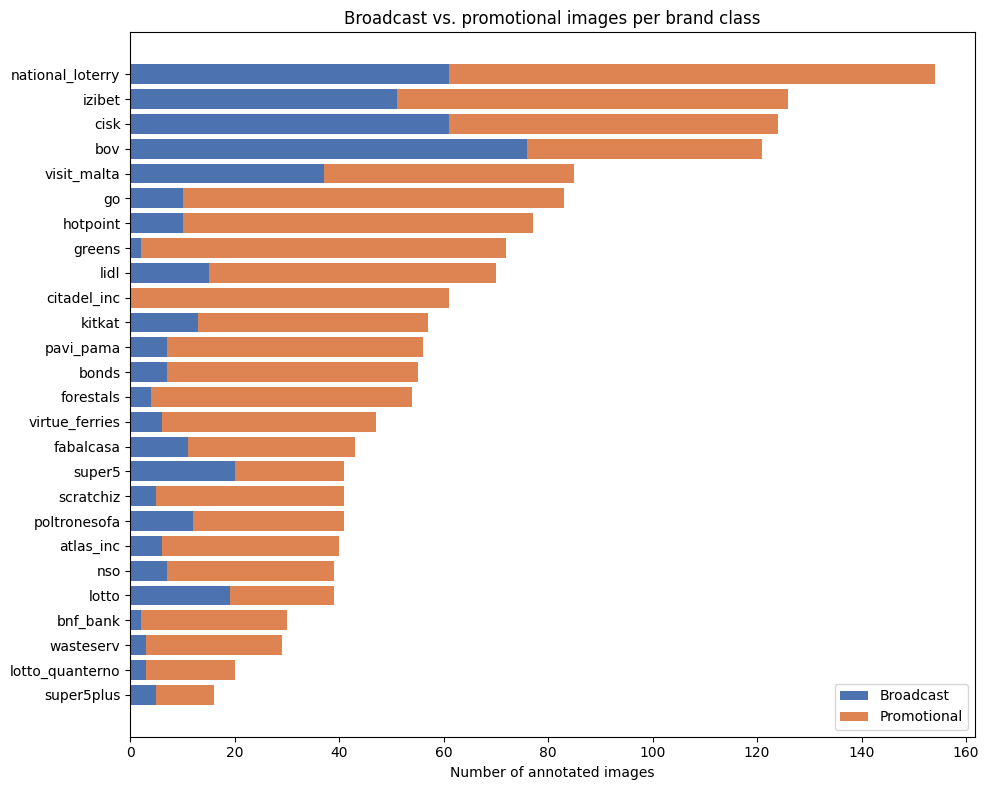

In [ ]:
df = pd.DataFrame(rows).sort_values('total_images', ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(df['brand'], df['broadcast_images'], label='Broadcast', color='#4C72B0')
ax.barh(df['brand'], df['primary_images'], left=df['broadcast_images'], label='Promotional', color='#DD8452')
ax.set_xlabel('Number of annotated images')
ax.set_title('Broadcast vs. promotional images per brand class')
ax.legend()
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('brand_image_source_breakdown.png', dpi=200, bbox_inches='tight')
plt.show()

## 3. Phase 2 fine-tuning at 416 px

A single Colab session cannot be relied on to stay connected for a full run, so training happens in chunks. After each chunk the run folder is zipped to Drive and an epoch counter is updated. On re-run the cell restores the latest checkpoint and continues. If the zip fails, the counter is not advanced, so the same chunk is retried instead of silently lost.

Shared hyperparameters: `imgsz=416`, `batch=16`, `patience=15`, `mosaic=0.5`, `fraction=1.0`, `workers=2`, 26-class detection (`single_cls=False`).

*The saved outputs are from re-runs after training had finished, so both cells report "Already reached 100 epochs".*

### 3.1 YOLOv8n
Starts from the Phase 1 LogoDet-3K checkpoint; 100 epochs in chunks of 50. (Completed: 100/100 epochs.)

In [ ]:
# Fine-tuning is performed in fixed-size chunks with checkpointing to Drive after
# each chunk, since a single Colab session cannot be relied upon to stay connected
# for the full training duration.
RUN_NAME = 'yolov8n_finetune_malta_mixed_v2'
LOCAL_RUN_DIR = f'runs/detect/finetune/{RUN_NAME}'
LOCAL_WEIGHTS = f'{LOCAL_RUN_DIR}/weights/last.pt'
DRIVE_RUN_ZIP = f'{FINETUNE_DIR}/{RUN_NAME}_run.zip'
PROGRESS_FILE = f'{FINETUNE_DIR}/{RUN_NAME}_epochs_done.txt'

CHUNK_SIZE = 50
TOTAL_EPOCHS = 100
PRETRAINED_CKPT = f'{LOGODET_CHECKPOINT_DIR}/yolov8n_pretrained_final.pt'

if not os.path.exists(LOCAL_WEIGHTS) and os.path.exists(DRIVE_RUN_ZIP):
    print("Restoring last checkpoint from Drive...")
    shutil.copy(DRIVE_RUN_ZIP, f'{RUN_NAME}_run.zip')
    !unzip -oq {RUN_NAME}_run.zip
    print("Restored.")

completed_epochs = 0
if os.path.exists(PROGRESS_FILE):
    with open(PROGRESS_FILE) as f:
        completed_epochs = int(f.read().strip())

remaining = TOTAL_EPOCHS - completed_epochs
this_chunk = min(CHUNK_SIZE, remaining)

print(f"{completed_epochs} epoch(s) already done. Training {this_chunk} more "
      f"(target: {completed_epochs + this_chunk}/{TOTAL_EPOCHS}).")

if remaining <= 0:
    print(f"Already reached {TOTAL_EPOCHS} epochs.")
else:
    if os.path.exists(LOCAL_WEIGHTS):
        model = YOLO(LOCAL_WEIGHTS)
        print("Continuing from existing local checkpoint.")
    else:
        model = YOLO(PRETRAINED_CKPT)
        print("Starting fine-tuning fresh from the Phase 1 (LogoDet-3K) checkpoint.")

    results = model.train(
        data=DATASET_YAML_MIXED_V2,
        epochs=this_chunk,
        patience=15,       # early stopping if validation mAP does not improve for 15 epochs
        imgsz=416,
        batch=16,
        workers=2,
        cache=False,
        mosaic=0.5,
        fraction=1.0,
        single_cls=False,  # 26-class detection, not the class-agnostic Phase 1 setting
        project='finetune',
        name=RUN_NAME,
        exist_ok=True
    )

    print("Backing up run to Drive...")
    !cd /content && zip -qr {RUN_NAME}_run.zip {LOCAL_RUN_DIR}

    zip_success = os.path.exists(f'{RUN_NAME}_run.zip') and os.path.getsize(f'{RUN_NAME}_run.zip') > 0
    if zip_success:
        shutil.copy(f'{RUN_NAME}_run.zip', DRIVE_RUN_ZIP)
        completed_epochs += this_chunk
        with open(PROGRESS_FILE, 'w') as f:
            f.write(str(completed_epochs))
        print(f"Backed up. {completed_epochs}/{TOTAL_EPOCHS} epochs done.")

        # A short pause before re-checking Drive, since file propagation can lag
        # slightly behind the copy operation completing.
        import time
        time.sleep(15)
        drive_ok = os.path.exists(DRIVE_RUN_ZIP) and os.path.exists(PROGRESS_FILE)
        print(f"Re-verified on Drive after 15s pause: {drive_ok}")
        if not drive_ok:
            print("WARNING: backup may not have synced to Drive yet -- "
                  "do not close this session until this shows True.")
    else:
        print("ZIP FAILED -- progress NOT updated, so a rerun will safely retry "
              "this same chunk instead of silently losing it.")

100 epoch(s) already done. Training 0 more (target: 100/100).
Already reached 100 epochs.


### 3.2 YOLO11n
Same setup as 3.1, run as a single 100-epoch chunk. (Completed: 100/100 epochs.)

In [ ]:
RUN_NAME = 'yolo11n_finetune_malta_mixed_v2'
LOCAL_RUN_DIR = f'runs/detect/finetune/{RUN_NAME}'
LOCAL_WEIGHTS = f'{LOCAL_RUN_DIR}/weights/last.pt'
DRIVE_RUN_ZIP = f'{FINETUNE_DIR}/{RUN_NAME}_run.zip'
PROGRESS_FILE = f'{FINETUNE_DIR}/{RUN_NAME}_epochs_done.txt'

CHUNK_SIZE = 100
TOTAL_EPOCHS = 100
PRETRAINED_CKPT = f'{LOGODET_CHECKPOINT_DIR}/yolo11n_pretrained_final.pt'

if not os.path.exists(LOCAL_WEIGHTS) and os.path.exists(DRIVE_RUN_ZIP):
    print("Restoring last checkpoint from Drive...")
    shutil.copy(DRIVE_RUN_ZIP, f'{RUN_NAME}_run.zip')
    !unzip -oq {RUN_NAME}_run.zip
    print("Restored.")

completed_epochs = 0
if os.path.exists(PROGRESS_FILE):
    with open(PROGRESS_FILE) as f:
        completed_epochs = int(f.read().strip())

remaining = TOTAL_EPOCHS - completed_epochs
this_chunk = min(CHUNK_SIZE, remaining)

print(f"{completed_epochs} epoch(s) already done. Training {this_chunk} more "
      f"(target: {completed_epochs + this_chunk}/{TOTAL_EPOCHS}).")

if remaining <= 0:
    print(f"Already reached {TOTAL_EPOCHS} epochs.")
else:
    if os.path.exists(LOCAL_WEIGHTS):
        model = YOLO(LOCAL_WEIGHTS)
        print("Continuing from existing local checkpoint.")
    else:
        model = YOLO(PRETRAINED_CKPT)
        print("Starting fine-tuning fresh from the Phase 1 (LogoDet-3K) checkpoint.")

    results = model.train(
        data=DATASET_YAML_MIXED_V2,
        epochs=this_chunk,
        patience=15,
        imgsz=416,
        batch=16,
        workers=2,
        cache=False,
        mosaic=0.5,
        fraction=1.0,
        single_cls=False,
        project='finetune',
        name=RUN_NAME,
        exist_ok=True
    )

    print("Backing up run to Drive...")
    !cd /content && zip -qr {RUN_NAME}_run.zip {LOCAL_RUN_DIR}

    zip_success = os.path.exists(f'{RUN_NAME}_run.zip') and os.path.getsize(f'{RUN_NAME}_run.zip') > 0
    if zip_success:
        shutil.copy(f'{RUN_NAME}_run.zip', DRIVE_RUN_ZIP)
        completed_epochs += this_chunk
        with open(PROGRESS_FILE, 'w') as f:
            f.write(str(completed_epochs))
        print(f"Backed up. {completed_epochs}/{TOTAL_EPOCHS} epochs done.")

        import time
        time.sleep(15)
        drive_ok = os.path.exists(DRIVE_RUN_ZIP) and os.path.exists(PROGRESS_FILE)
        print(f"Re-verified on Drive after 15s pause: {drive_ok}")
        if not drive_ok:
            print("WARNING: backup may not have synced to Drive yet -- "
                  "do not close this session until this shows True.")
    else:
        print("ZIP FAILED -- progress NOT updated, so a rerun will safely retry "
              "this same chunk instead of silently losing it.")

100 epoch(s) already done. Training 0 more (target: 100/100).
Already reached 100 epochs.


## 4. Held-out test-set evaluation (416 px)

### 4.1 YOLOv8n
Evaluates the best YOLOv8n weights (from the local run folder) on the test split.

*Result: mAP50 0.4081 · mAP50-95 0.3105 · P 0.6021 · R 0.3008*

> This cell does not copy `best.pt` to `finetune_checkpoints/yolov8n_finetune_malta_mixed_v2_final.pt`, but 4.3 and Section 5 load that file. It already exists on Drive from an earlier run. For a clean re-run, copy it the same way 4.2 does for YOLO11n.

In [ ]:
model = YOLO('runs/detect/finetune/yolov8n_finetune_malta_mixed_v2/weights/best.pt')
r = model.val(
    data=DATASET_YAML_MIXED_V2,
    split='test',
    imgsz=416,
    batch=16,
    plots=True,
    project='runs/detect/finetune',
    name='YOLOv8n_mixed_v2_TEST_EVAL'
)
print(f"\nOverall — mAP50: {r.box.map50:.4f} | mAP50-95: {r.box.map:.4f} | P: {r.box.mp:.4f} | R: {r.box.mr:.4f}")

Ultralytics 8.4.156 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8n summary (fused): 72 layers, 3,010,718 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1673.5±972.6 MB/s, size: 207.1 KB)
val: Scanning /content/yolo_dataset_malta_mixed_v2/labels/test... 46 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 46/46 572.9it/s 0.1s
val: New cache created: /content/yolo_dataset_malta_mixed_v2/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 1.2it/s 2.5s
                   all         46        148      0.602      0.301      0.408       0.31
             atlas_inc          3          3          1      0.646      0.995      0.597
              bnf_bank          2          2      0.584        0.5      0.828      0.679
                   bov         18         65     0.0328     0.0769     0.0086    0.00358
                  cisk         13         25   

### 4.2 YOLO11n
Copies the best YOLO11n weights to Drive as the final checkpoint, then evaluates on the test split.

*Result: mAP50 0.4711 · mAP50-95 0.3607 · P 0.5884 · R 0.4687*

In [ ]:
shutil.copy(
    'runs/detect/finetune/yolo11n_finetune_malta_mixed_v2/weights/best.pt',
    f'{FINETUNE_DIR}/yolo11n_finetune_malta_mixed_v2_final.pt'
)

model = YOLO(f'{FINETUNE_DIR}/yolo11n_finetune_malta_mixed_v2_final.pt')
r = model.val(
    data=DATASET_YAML_MIXED_V2,
    split='test',
    imgsz=416,
    batch=16,
    plots=True,
    project='runs/detect/finetune',
    name='YOLO11n_mixed_v2_TEST_EVAL'
)
print(f"\nOverall -- mAP50: {r.box.map50:.4f} | mAP50-95: {r.box.map:.4f} | P: {r.box.mp:.4f} | R: {r.box.mr:.4f}")

Ultralytics 8.4.156 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 100 layers, 2,587,222 parameters, 0 gradients, 6.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1837.0±594.1 MB/s, size: 167.1 KB)
val: Scanning /content/yolo_dataset_malta_mixed_v2/labels/test.cache... 46 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 46/46 12.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 2.4it/s 1.3s
                   all         46        148      0.588      0.469      0.471      0.361
             atlas_inc          3          3       0.77          1      0.995      0.813
              bnf_bank          2          2      0.762          1      0.995      0.755
                   bov         18         65      0.132      0.246      0.125      0.063
                  cisk         13         25      0.128       0.08     0.0389     0.0151
                    go        

### 4.3 Re-check from the saved Drive checkpoints
Re-evaluates both models from the `*_final.pt` files on Drive (the files Section 5 uses) to confirm they reproduce 4.1 and 4.2. Both match exactly.

In [ ]:
model = YOLO(f'{FINETUNE_DIR}/yolov8n_finetune_malta_mixed_v2_final.pt')
r = model.val(
    data=DATASET_YAML_MIXED_V2,
    split='test',
    imgsz=416,
    batch=16,
    plots=True,
    project='runs/detect/finetune',
    name='YOLOv8n_mixed_v2_TEST_EVAL'
)
print(f"\nOverall — mAP50: {r.box.map50:.4f} | mAP50-95: {r.box.map:.4f} | P: {r.box.mp:.4f} | R: {r.box.mr:.4f}")
# Should read: mAP50: 0.4081 | mAP50-95: 0.3105 | P: 0.6021 | R: 0.3008

Ultralytics 8.4.156 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8n summary (fused): 72 layers, 3,010,718 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1189.9±464.0 MB/s, size: 176.8 KB)
val: Scanning /content/yolo_dataset_malta_mixed_v2/labels/test.cache... 46 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 46/46 11.3Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 1.2it/s 2.6s
                   all         46        148      0.602      0.301      0.408       0.31
             atlas_inc          3          3          1      0.646      0.995      0.597
              bnf_bank          2          2      0.584        0.5      0.828      0.679
                   bov         18         65     0.0328     0.0769     0.0086    0.00358
                  cisk         13         25      0.501       0.04     0.0406    0.00503
                    go         

In [ ]:
model = YOLO(f'{FINETUNE_DIR}/yolo11n_finetune_malta_mixed_v2_final.pt')
r = model.val(
    data=DATASET_YAML_MIXED_V2,
    split='test',
    imgsz=416,
    batch=16,
    plots=True,
    project='runs/detect/finetune',
    name='YOLO11n_mixed_v2_TEST_EVAL'
)
print(f"\nOverall -- mAP50: {r.box.map50:.4f} | mAP50-95: {r.box.map:.4f} | P: {r.box.mp:.4f} | R: {r.box.mr:.4f}")
# Should read: mAP50: 0.4711 | mAP50-95: 0.3607 | P: 0.5884 | R: 0.4687

Ultralytics 8.4.156 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 100 layers, 2,587,222 parameters, 0 gradients, 6.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2084.9±574.8 MB/s, size: 212.2 KB)
val: Scanning /content/yolo_dataset_malta_mixed_v2/labels/test.cache... 46 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 46/46 11.3Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 1.5it/s 2.0s
                   all         46        148      0.588      0.469      0.471      0.361
             atlas_inc          3          3       0.77          1      0.995      0.813
              bnf_bank          2          2      0.762          1      0.995      0.755
                   bov         18         65      0.132      0.246      0.125      0.063
                  cisk         13         25      0.128       0.08     0.0389     0.0151
                    go        

## 5. YOLOv8n vs YOLO11n comparison

### 5.1 Plot colour cycle
Reorders matplotlib's `tab20` palette so neighbouring classes don't share a light/dark hue pair. `linestyles` is available for manually drawn per-class curves where a figure must stay readable in greyscale.

In [ ]:
# Reorder tab20 so its dark/light pairs are spread apart: same 20 colours, but
# classes adjacent in the legend/cycle no longer share a hue.
import matplotlib.pyplot as plt
from matplotlib import cycler

tab20 = plt.get_cmap('tab20').colors
# tab20 is ordered as 10 (dark, light) pairs back-to-back: interleave by
# taking all the dark shades first, then all the light shades.
reordered = list(tab20[0::2]) + list(tab20[1::2])
plt.rcParams['axes.prop_cycle'] = cycler(color=reordered)

print(f"Reordered {len(reordered)}-color cycle set -- adjacent classes no longer share a hue pair.")

# Line styles for manually plotted curves (Ultralytics' built-in PR plot does not
# accept a linestyle), so classes remain distinguishable in greyscale.
linestyles = ['-', '--', '-.', ':'] * 4  # cycles through 4 styles
# usage : ax.plot(x, y, color=..., linestyle=linestyles[i], ...)

Reordered 20-color cycle set -- adjacent classes no longer share a hue pair.


### 5.2 Test-time resolution sensitivity probe (640 px and 1024 px)
The **same 416 px-trained checkpoints** evaluated at higher input resolutions. This is not a resolution ablation (see Section 6 for that).

The first two cells evaluate each model at 640 px on its own. The next two are standalone comparison cells (Drive mount, config, dataset restore, helpers, evaluation and the full set of figures/tables) at 640 px and 1024 px. They also define `OUTPUT_DIR` and `DATASET_YAML`, which 5.3 relies on.

| Eval imgsz | YOLOv8n mAP50 | YOLOv8n mAP50-95 | YOLO11n mAP50 | YOLO11n mAP50-95 |
|---|---|---|---|---|
| 416 (reported, 5.3) | 0.408 | 0.310 | 0.471 | 0.361 |
| 640 | 0.485 | 0.351 | 0.571 | 0.375 |
| 1024 | 0.370 | 0.259 | 0.502 | 0.365 |

> These cells write to the same Drive PNG/CSV filenames as 5.3, so 5.3 must be run **last** for the Drive files to hold the reported 416 px results.

#### Parameter 640

In [ ]:
model = YOLO(f'{FINETUNE_DIR}/yolov8n_finetune_malta_mixed_v2_final.pt')
r_640 = model.val(
    data=DATASET_YAML_MIXED_V2,
    split='test',
    imgsz=640,   # different from the imgsz=416 used to produce Table 5.1
    batch=16,
    plots=True,
    project='runs/detect/finetune',
    name='YOLOv8n_mixed_v2_TEST_EVAL_640'
)
print(f"\nOverall — mAP50: {r_640.box.map50:.4f} | mAP50-95: {r_640.box.map:.4f} | P: {r_640.box.mp:.4f} | R: {r_640.box.mr:.4f}")

Ultralytics 8.4.156 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8n summary (fused): 72 layers, 3,010,718 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1623.8±249.7 MB/s, size: 175.6 KB)
val: Scanning /content/yolo_dataset_malta_mixed_v2/labels/test.cache... 46 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 46/46 10.2Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 1.2s/it 3.6s
                   all         46        148      0.327       0.46      0.485      0.351
             atlas_inc          3          3      0.372       0.41      0.597       0.27
              bnf_bank          2          2      0.736          1      0.995      0.796
                   bov         18         65     0.0917        0.4      0.193     0.0899
                  cisk         13         25     0.0976       0.12       0.12     0.0325
                    go         

In [ ]:
model = YOLO(f'{FINETUNE_DIR}/yolo11n_finetune_malta_mixed_v2_final.pt')
r_640 = model.val(data=DATASET_YAML_MIXED_V2, split='test', imgsz=640, batch=16,
                   plots=True, project='runs/detect/finetune', name='YOLO11n_mixed_v2_TEST_EVAL_640')
print(f"\nOverall — mAP50: {r_640.box.map50:.4f} | mAP50-95: {r_640.box.map:.4f} | P: {r_640.box.mp:.4f} | R: {r_640.box.mr:.4f}")

Ultralytics 8.4.156 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 100 layers, 2,587,222 parameters, 0 gradients, 6.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1701.6±487.0 MB/s, size: 141.9 KB)
val: Scanning /content/yolo_dataset_malta_mixed_v2/labels/test.cache... 46 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 46/46 10.7Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 1.2it/s 2.6s
                   all         46        148      0.584      0.558      0.571      0.375
             atlas_inc          3          3       0.67          1      0.995      0.608
              bnf_bank          2          2      0.759          1      0.995      0.597
                   bov         18         65      0.445      0.415      0.378      0.196
                  cisk         13         25      0.124       0.16      0.125      0.033
                    go        

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
GPU available: True
GPU: Tesla T4
Dataset already present locally.

--- Sanity Check ---
Dataset Drive directory : /content/drive/MyDrive/thesis-maltese-dataset
Fine-tune directory     : /content/drive/MyDrive/thesis-maltese-dataset/finetune_checkpoints
Dataset YAML            : /content/yolo_dataset_malta_mixed_v2/malta_brands.yaml
YAML exists             : True
YOLOv8n checkpoint exists : True
YOLO11n checkpoint exists : True

Evaluating both models at imgsz=640, batch=16...

Ultralytics 8.4.157 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8n summary (fused): 72 layers, 3,010,718 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2869.0±850.1 MB/s, size: 185.5 KB)
val: Scanning /content/yolo_dataset_malta_mixed_v2/labels/test.cache... 46 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 46/46 6.7M

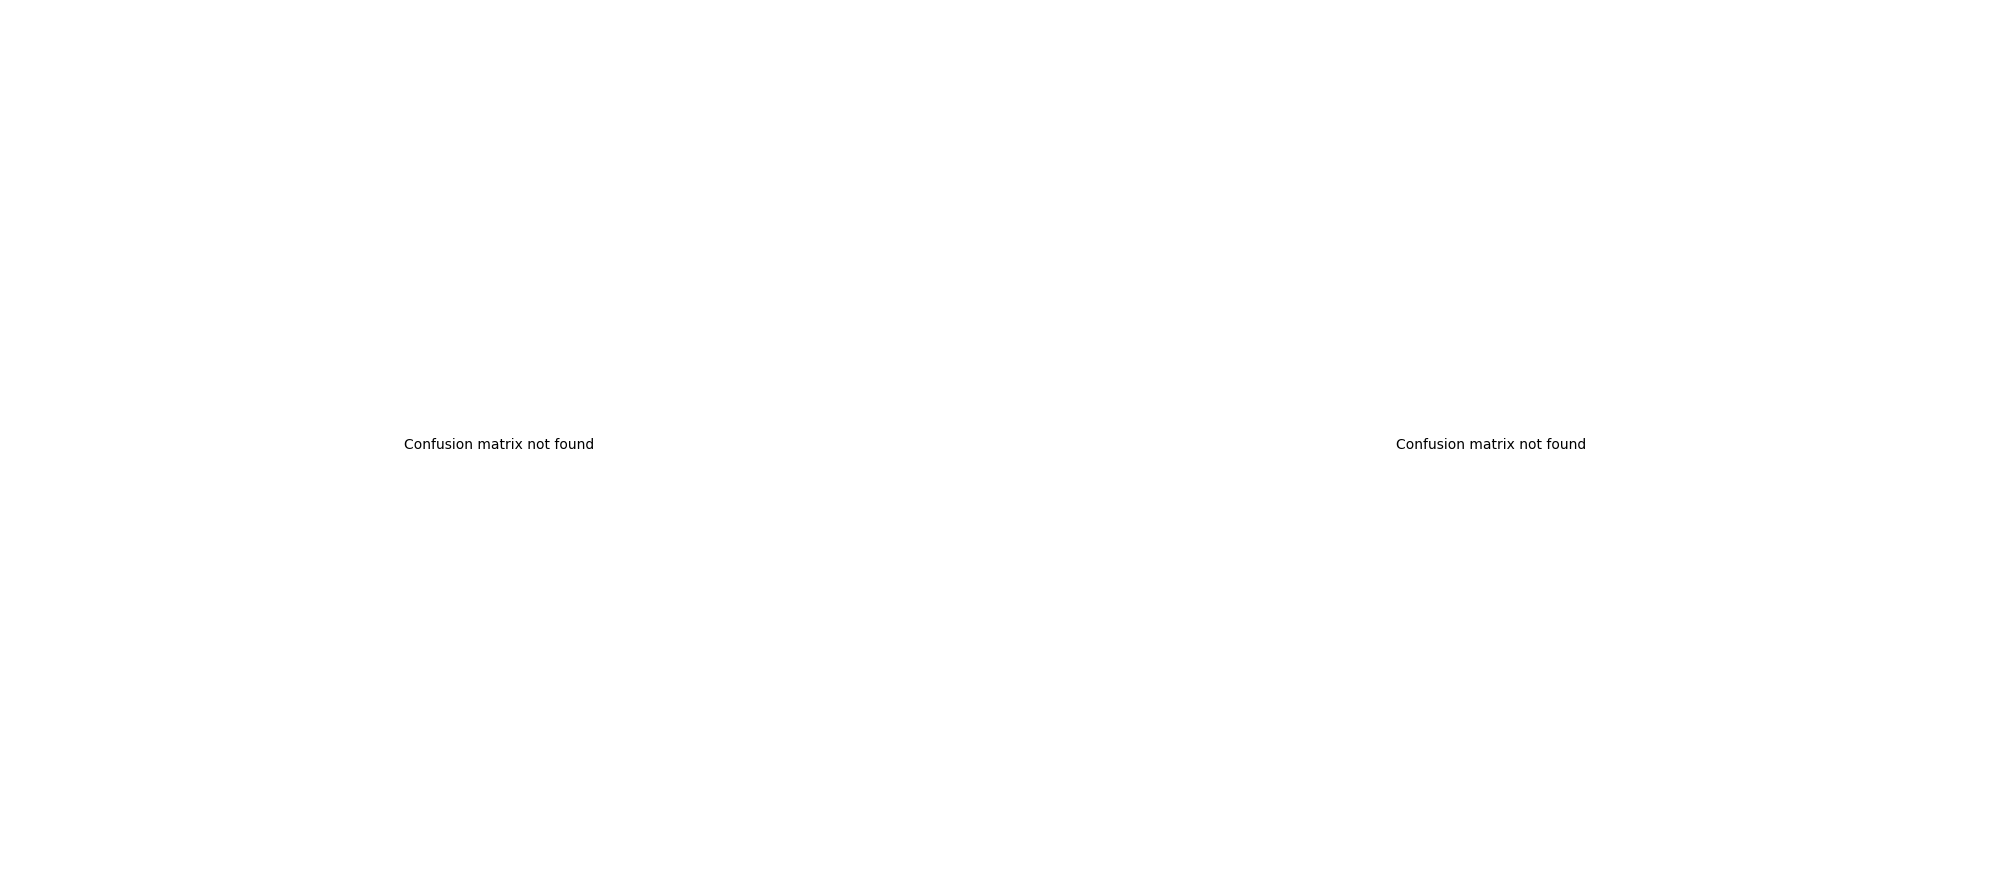

Saved combined confusion matrix to:
/content/drive/MyDrive/thesis-maltese-dataset/eval_confusion_matrices_side_by_side.png


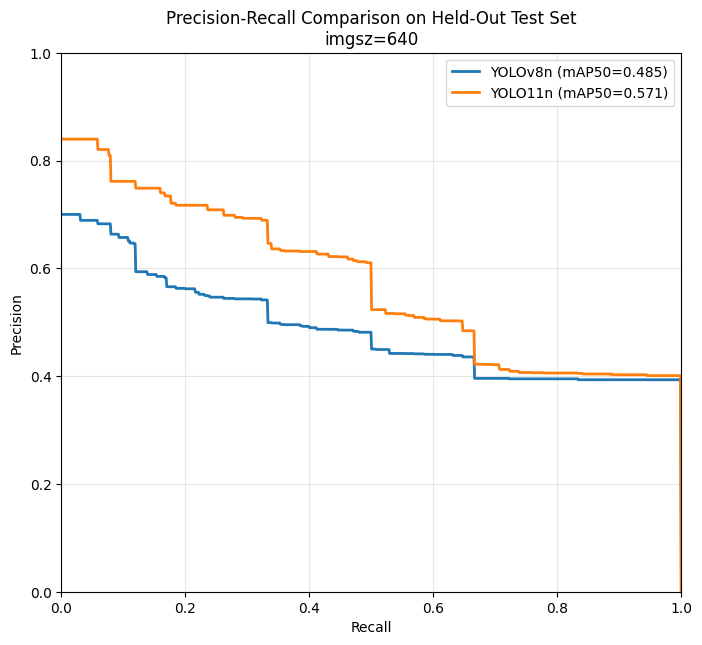

Saved PR comparison to:
/content/drive/MyDrive/thesis-maltese-dataset/eval_pr_curve_comparison.png


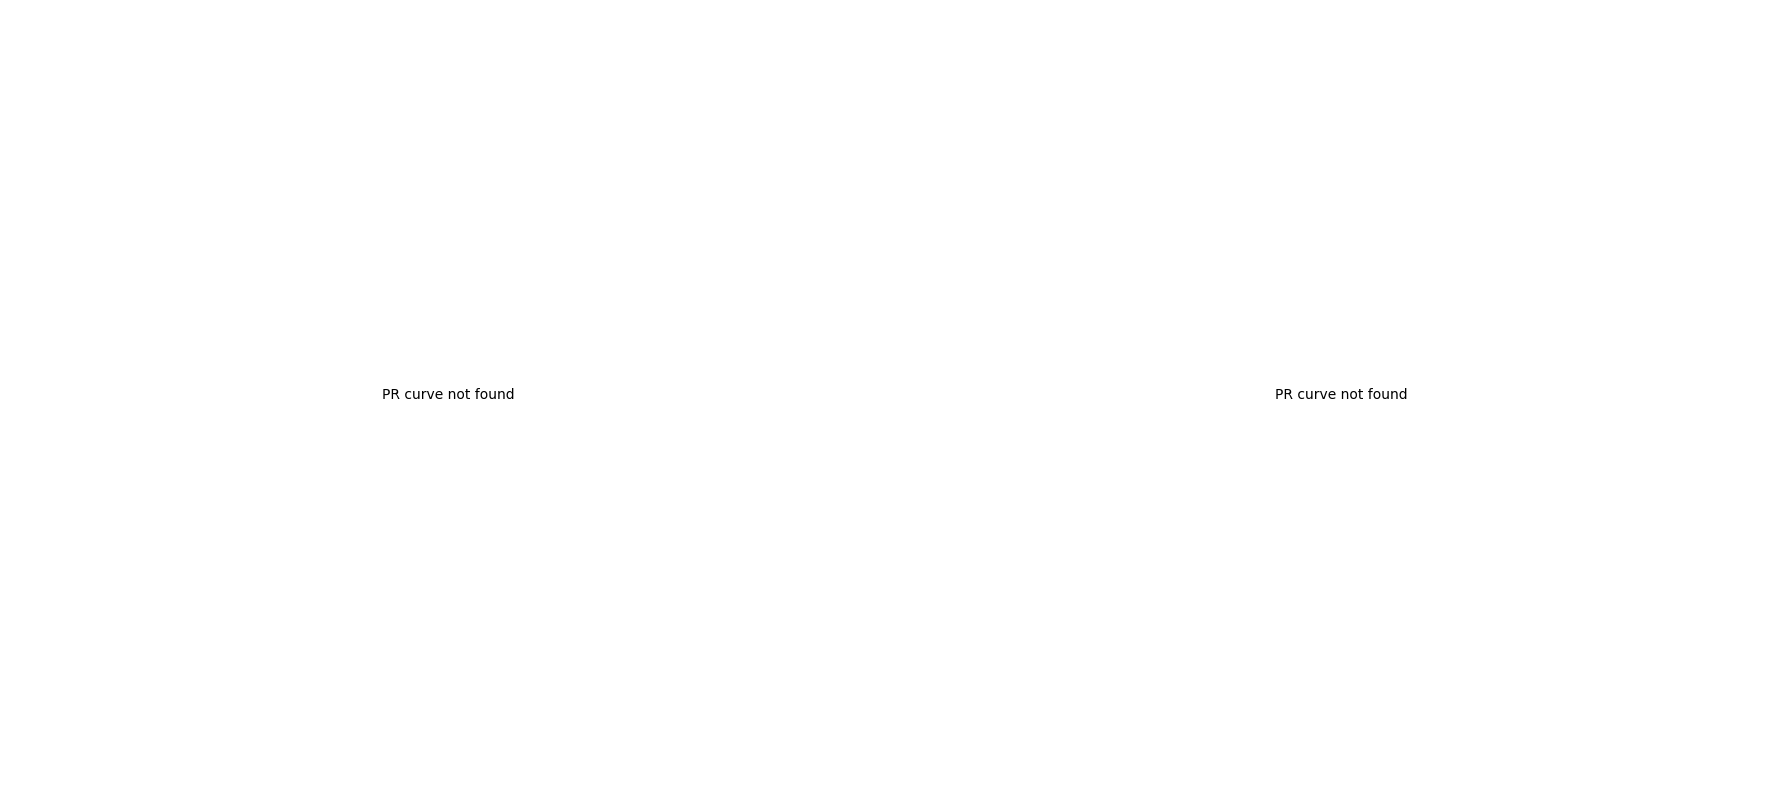


Individual PR curve source files:
  YOLOv8n: None
  YOLO11n: None

Classes with zero test-set instances (13/26):
['bonds', 'citadel_inc', 'fabalcasa', 'forestals', 'hotpoint', 'kitkat', 'lotto', 'nso', 'poltronesofa', 'pavi_pama', 'scratchiz', 'super5plus', 'wasteserv']

Saved per-class comparison to:
/content/drive/MyDrive/thesis-maltese-dataset/eval_per_class_comparison.csv


,yolov8n_P,yolov8n_R,yolov8n_mAP50,yolov8n_mAP50-95,yolo11n_P,yolo11n_R,yolo11n_mAP50,yolo11n_mAP50-95,test_instances
class,,,,,,,,,
atlas_inc,0.372,0.410,0.597,0.270,0.670,1.000,0.995,0.608,3
bnf_bank,0.736,1.000,0.995,0.796,0.759,1.000,0.995,0.597,2
bov,0.092,0.400,0.193,0.090,0.445,0.415,0.378,0.196,65
cisk,0.098,0.120,0.120,0.032,0.124,0.160,0.125,0.033,25
go,0.193,0.129,0.168,0.134,0.318,0.333,0.168,0.134,3
greens,0.000,0.000,0.041,0.029,1.000,0.000,0.071,0.035,2
izibet,0.181,0.167,0.085,0.030,1.000,0.000,0.132,0.063,18
lidl,0.645,1.000,0.995,0.920,0.454,1.000,0.995,0.945,2
lotto_quanterno,0.693,1.000,0.995,0.796,0.391,1.000,0.995,0.797,3



--- Background-Confusion Rates ---
atlas_inc            instances=  3 | v8n=100% | v11n=0%
bnf_bank             instances=  2 | v8n=0% | v11n=0%
bov                  instances= 65 | v8n=74% | v11n=63%
cisk                 instances= 25 | v8n=92% | v11n=84%
go                   instances=  3 | v8n=100% | v11n=67%
greens               instances=  2 | v8n=100% | v11n=50%
izibet               instances= 18 | v8n=67% | v11n=50%
lidl                 instances=  2 | v8n=0% | v11n=0%
lotto_quanterno      instances=  3 | v8n=0% | v11n=0%
national_loterry     instances=  3 | v8n=0% | v11n=0%
super5               instances=  3 | v8n=100% | v11n=33%
virtue_ferries       instances=  2 | v8n=100% | v11n=50%
visit_malta          instances= 17 | v8n=100% | v11n=82%

Saved background-confusion table to:
/content/drive/MyDrive/thesis-maltese-dataset/eval_background_confusion_rates.csv

EVALUATION COMPLETE

Evaluation resolution:
  imgsz = 640

Generated thesis/evaluation files:
  /content/drive/MyDrive

In [ ]:
# ============================================================================
# Standalone YOLO Evaluation & Comparison
# Run this cell first in a fresh Google Colab session.
#
# Provides everything needed to compare the fine-tuned YOLOv8n and YOLO11n
# models without rerunning the dataset-building or training cells.
#
# Safe to run multiple times.
# ============================================================================

import os
import glob

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import torch

from google.colab import drive


# 1. Environment setup
drive.mount("/content/drive")

print("GPU available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


# Install Ultralytics if needed.
!pip install -q ultralytics albumentations

from ultralytics import YOLO



# 2. Configuration
DATASET_DRIVE_DIR = "/content/drive/MyDrive/thesis-maltese-dataset"
FINETUNE_DIR = f"{DATASET_DRIVE_DIR}/finetune_checkpoints"

OUTPUT_DIR = "/content/yolo_dataset_malta_mixed_v2"
DATASET_YAML = f"{OUTPUT_DIR}/malta_brands.yaml"

# Use the same evaluation resolution for both models.
# Set to 640 only if 640 is the resolution you intend to report.
EVAL_IMGSZ = 640
EVAL_BATCH_SIZE = 16

RUNS_DIR = "runs/detect/finetune"

MODEL_PATHS = {
    "YOLOv8n": f"{FINETUNE_DIR}/yolov8n_finetune_malta_mixed_v2_final.pt",
    "YOLO11n": f"{FINETUNE_DIR}/yolo11n_finetune_malta_mixed_v2_final.pt",
}

BRANDS = [
    "atlas_inc",
    "bnf_bank",
    "bonds",
    "bov",
    "cisk",
    "citadel_inc",
    "fabalcasa",
    "forestals",
    "go",
    "greens",
    "hotpoint",
    "izibet",
    "kitkat",
    "lidl",
    "lotto",
    "lotto_quanterno",
    "national_loterry",
    "nso",
    "poltronesofa",
    "pavi_pama",
    "scratchiz",
    "super5",
    "super5plus",
    "virtue_ferries",
    "visit_malta",
    "wasteserv",
]

BRAND2IDX = {brand: i for i, brand in enumerate(BRANDS)}


# 3. Restore dataset if necessary
if not os.path.exists(OUTPUT_DIR):
    zip_path = f"{DATASET_DRIVE_DIR}/yolo_dataset_malta_mixed_v2.zip"

    print("Local dataset not found.")
    print("Restoring dataset from Drive backup...")

    if not os.path.exists(zip_path):
        raise FileNotFoundError(
            f"Dataset backup not found at:\n{zip_path}\n\n"
            "Rerun the original dataset-building cells instead."
        )

    !unzip -q "{zip_path}" -d /content
    print("Dataset restored successfully.")

else:
    print("Dataset already present locally.")


# 4. Sanity checks
print("\n--- Sanity Check ---")
print(f"Dataset Drive directory : {DATASET_DRIVE_DIR}")
print(f"Fine-tune directory     : {FINETUNE_DIR}")
print(f"Dataset YAML            : {DATASET_YAML}")
print(f"YAML exists             : {os.path.exists(DATASET_YAML)}")

for model_name, model_path in MODEL_PATHS.items():
    print(f"{model_name} checkpoint exists : {os.path.exists(model_path)}")

if not os.path.exists(DATASET_YAML):
    raise FileNotFoundError(f"Dataset YAML not found: {DATASET_YAML}")

for model_name, model_path in MODEL_PATHS.items():
    if not os.path.exists(model_path):
        raise FileNotFoundError(
            f"{model_name} checkpoint not found: {model_path}"
        )


# 5. Helper functions
def latest_plot(run_name_prefix, filename):
    """Return the most recently generated plot matching a run prefix."""
    pattern = f"{RUNS_DIR}/{run_name_prefix}*/{filename}"

    matches = sorted(
        glob.glob(pattern),
        key=os.path.getmtime,
    )

    return matches[-1] if matches else None


def get_pr_curve(results):
    """
    Extract the mean all-class Precision-Recall curve from an Ultralytics
    validation results object.

    Handles Ultralytics versions where curves_results tuples differ slightly
    in structure.
    """
    curves = getattr(results, "curves_results", None)
    names = getattr(results, "curves", None)

    if curves is None or names is None:
        raise RuntimeError(
            "This Ultralytics version does not expose curves_results."
        )

    for curve_tuple, name in zip(curves, names):
        if "Precision-Recall" not in name:
            continue

        recall = np.asarray(curve_tuple[0])
        precision = np.asarray(curve_tuple[1])

        # Average across classes if per-class curves are returned.
        if precision.ndim > 1:
            precision = precision.mean(axis=0)

        return recall, precision

    raise RuntimeError("Precision-Recall curve not found in curves_results.")


def per_class_df(results, model_name):
    """Create a per-class metric DataFrame from Ultralytics results."""
    box = results.box
    rows = []

    for i, cls_idx in enumerate(box.ap_class_index):
        cls_idx = int(cls_idx)

        rows.append(
            {
                "class": BRANDS[cls_idx],
                f"{model_name}_P": box.p[i],
                f"{model_name}_R": box.r[i],
                f"{model_name}_mAP50": box.ap50[i],
                f"{model_name}_mAP50-95": box.ap[i],
            }
        )

    return pd.DataFrame(rows).set_index("class")


def count_test_instances(label_dir, num_classes):
    """Count ground-truth object instances for each class in YOLO labels."""
    counts = [0] * num_classes

    for label_path in glob.glob(f"{label_dir}/*.txt"):
        with open(label_path, "r") as file:
            for line in file:
                parts = line.split()

                if not parts:
                    continue

                class_id = int(float(parts[0]))

                if 0 <= class_id < num_classes:
                    counts[class_id] += 1

    return counts


def background_confusion_rates(results, brands):
    """
    Calculate the proportion of ground-truth instances for each class that
    were classified as background (false negatives).

    Ultralytics confusion matrix:
        rows    = predicted classes
        columns = true classes
        final row/column = background
    """
    cm = np.asarray(results.confusion_matrix.matrix)

    num_classes = len(brands)
    background_row = num_classes

    rates = {}

    for class_idx, class_name in enumerate(brands):
        true_instances = cm[:, class_idx].sum()

        if true_instances > 0:
            rates[class_name] = (
                cm[background_row, class_idx] / true_instances
            )

    return rates


# 6. Evaluate both models on the held-out test set
print(
    f"\nEvaluating both models at imgsz={EVAL_IMGSZ}, "
    f"batch={EVAL_BATCH_SIZE}...\n"
)

model8 = YOLO(MODEL_PATHS["YOLOv8n"])
r8 = model8.val(
    data=DATASET_YAML,
    split="test",
    imgsz=EVAL_IMGSZ,
    batch=EVAL_BATCH_SIZE,
    plots=True,
    project=RUNS_DIR,
    name=f"YOLOv8n_COMPARE_{EVAL_IMGSZ}",
)

model11 = YOLO(MODEL_PATHS["YOLO11n"])
r11 = model11.val(
    data=DATASET_YAML,
    split="test",
    imgsz=EVAL_IMGSZ,
    batch=EVAL_BATCH_SIZE,
    plots=True,
    project=RUNS_DIR,
    name=f"YOLO11n_COMPARE_{EVAL_IMGSZ}",
)


# 7. Overall metric comparison
print("\n--- Test-Set Results ---")

print(
    f"YOLOv8n  | "
    f"mAP50: {r8.box.map50:.3f} | "
    f"mAP50-95: {r8.box.map:.3f} | "
    f"P: {r8.box.mp:.3f} | "
    f"R: {r8.box.mr:.3f}"
)

print(
    f"YOLO11n  | "
    f"mAP50: {r11.box.map50:.3f} | "
    f"mAP50-95: {r11.box.map:.3f} | "
    f"P: {r11.box.mp:.3f} | "
    f"R: {r11.box.mr:.3f}"
)


# 8. Side-by-side normalized confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(20, 9))

confusion_specs = [
    (axes[0], "YOLOv8n_COMPARE", "YOLOv8n"),
    (axes[1], "YOLO11n_COMPARE", "YOLO11n"),
]

for ax, run_prefix, title in confusion_specs:
    path = latest_plot(
        run_prefix,
        "confusion_matrix_normalized.png",
    )

    if path:
        ax.imshow(mpimg.imread(path))
        ax.set_title(
            f"{title} — Normalised Confusion Matrix\n"
            f"Held-Out Test Set, imgsz={EVAL_IMGSZ}"
        )
        ax.axis("off")
    else:
        ax.text(
            0.5,
            0.5,
            "Confusion matrix not found",
            ha="center",
            va="center",
        )
        ax.axis("off")

plt.tight_layout()

confusion_output = (
    f"{DATASET_DRIVE_DIR}/eval_confusion_matrices_side_by_side.png"
)

plt.savefig(
    confusion_output,
    dpi=200,
    bbox_inches="tight",
)
plt.show()

print(f"Saved combined confusion matrix to:\n{confusion_output}")


# 9. Overlaid Precision-Recall comparison
try:
    rec8, prec8 = get_pr_curve(r8)
    rec11, prec11 = get_pr_curve(r11)

    plt.figure(figsize=(8, 7))

    plt.plot(
        rec8,
        prec8,
        label=f"YOLOv8n (mAP50={r8.box.map50:.3f})",
        linewidth=2,
    )

    plt.plot(
        rec11,
        prec11,
        label=f"YOLO11n (mAP50={r11.box.map50:.3f})",
        linewidth=2,
    )

    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(
        "Precision-Recall Comparison on Held-Out Test Set\n"
        f"imgsz={EVAL_IMGSZ}"
    )

    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.legend()
    plt.grid(alpha=0.3)

    pr_comparison_output = (
        f"{DATASET_DRIVE_DIR}/eval_pr_curve_comparison.png"
    )

    plt.savefig(
        pr_comparison_output,
        dpi=200,
        bbox_inches="tight",
    )
    plt.show()

    print(f"Saved PR comparison to:\n{pr_comparison_output}")

except RuntimeError as error:
    print(
        "\nCould not generate overlaid PR curves from results object."
    )
    print(f"Reason: {error}")
    print("Using Ultralytics' saved PR curves below instead.")


# ============================================================================
# 10. Ultralytics PR curves side by side
#
# Use the individual source PNGs for thesis Figures 5.1 and 5.2.
# The combined figure is mainly useful for direct comparison.
# ============================================================================

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

pr_curve_paths = {}

pr_specs = [
    (axes[0], "YOLOv8n_COMPARE", "YOLOv8n"),
    (axes[1], "YOLO11n_COMPARE", "YOLO11n"),
]

for ax, run_prefix, title in pr_specs:
    path = latest_plot(run_prefix, "BoxPR_curve.png")
    pr_curve_paths[title] = path

    if path:
        ax.imshow(mpimg.imread(path))
        ax.set_title(f"{title} PR Curve")
        ax.axis("off")
    else:
        ax.text(
            0.5,
            0.5,
            "PR curve not found",
            ha="center",
            va="center",
        )
        ax.axis("off")

plt.tight_layout()

pr_side_by_side_output = (
    f"{DATASET_DRIVE_DIR}/eval_pr_curves_side_by_side.png"
)

plt.savefig(
    pr_side_by_side_output,
    dpi=200,
    bbox_inches="tight",
)
plt.show()

print("\nIndividual PR curve source files:")
for title, path in pr_curve_paths.items():
    print(f"  {title}: {path}")


# 11. Per-class comparison — Table 5.2
df8 = per_class_df(r8, "yolov8n")
df11 = per_class_df(r11, "yolo11n")

comparison = df8.join(df11, how="outer")


# Add ground-truth test-set instance counts.
test_label_dir = f"{OUTPUT_DIR}/labels/test"

test_counts = count_test_instances(
    test_label_dir,
    len(BRANDS),
)

comparison["test_instances"] = [
    test_counts[BRAND2IDX[class_name]]
    for class_name in comparison.index
]


# Identify classes with zero test instances.
present_classes = set(comparison.index)

missing_from_test = [
    brand
    for brand in BRANDS
    if brand not in present_classes
]

print(
    f"\nClasses with zero test-set instances "
    f"({len(missing_from_test)}/{len(BRANDS)}):"
)

print(missing_from_test)


# Save table.
comparison_output = (
    f"{DATASET_DRIVE_DIR}/eval_per_class_comparison.csv"
)

comparison.to_csv(comparison_output)

print(f"\nSaved per-class comparison to:\n{comparison_output}")

display(comparison.round(3))


# 12. Background-confusion rates — Table 5.3
rates8 = background_confusion_rates(r8, BRANDS)
rates11 = background_confusion_rates(r11, BRANDS)

background_rows = []

for class_name in BRANDS:
    # Only include classes represented in the test-set confusion matrix.
    if class_name not in rates8 and class_name not in rates11:
        continue

    background_rows.append(
        {
            "class": class_name,
            "test_instances": test_counts[BRAND2IDX[class_name]],
            "yolov8n_background_rate": rates8.get(
                class_name,
                np.nan,
            ),
            "yolo11n_background_rate": rates11.get(
                class_name,
                np.nan,
            ),
        }
    )

background_comparison = (
    pd.DataFrame(background_rows)
    .set_index("class")
)

background_output = (
    f"{DATASET_DRIVE_DIR}/eval_background_confusion_rates.csv"
)

background_comparison.to_csv(background_output)

print("\n--- Background-Confusion Rates ---")

for class_name, row in background_comparison.iterrows():
    v8 = row["yolov8n_background_rate"]
    v11 = row["yolo11n_background_rate"]

    print(
        f"{class_name:20s} "
        f"instances={int(row['test_instances']):3d} | "
        f"v8n={v8:.0%} | "
        f"v11n={v11:.0%}"
    )

print(f"\nSaved background-confusion table to:\n{background_output}")


# 13. Output summary
print("\n" + "=" * 72)
print("EVALUATION COMPLETE")
print("=" * 72)

print(f"""
Evaluation resolution:
  imgsz = {EVAL_IMGSZ}

Generated thesis/evaluation files:
  {confusion_output}
  {pr_side_by_side_output}
  {comparison_output}
  {background_output}

Individual PR curves:
  YOLOv8n : {pr_curve_paths["YOLOv8n"]}
  YOLO11n : {pr_curve_paths["YOLO11n"]}
""")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
GPU available: True
GPU: Tesla T4
Dataset already present locally.

--- Sanity Check ---
Dataset Drive directory : /content/drive/MyDrive/thesis-maltese-dataset
Fine-tune directory     : /content/drive/MyDrive/thesis-maltese-dataset/finetune_checkpoints
Dataset YAML            : /content/yolo_dataset_malta_mixed_v2/malta_brands.yaml
YAML exists             : True
YOLOv8n checkpoint exists : True
YOLO11n checkpoint exists : True

Evaluating both models at imgsz=1024, batch=16...

Ultralytics 8.4.157 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8n summary (fused): 72 layers, 3,010,718 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3190.7±1324.6 MB/s, size: 179.9 KB)
val: Scanning /content/yolo_dataset_malta_mixed_v2/labels/test.cache... 46 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 46/46 10

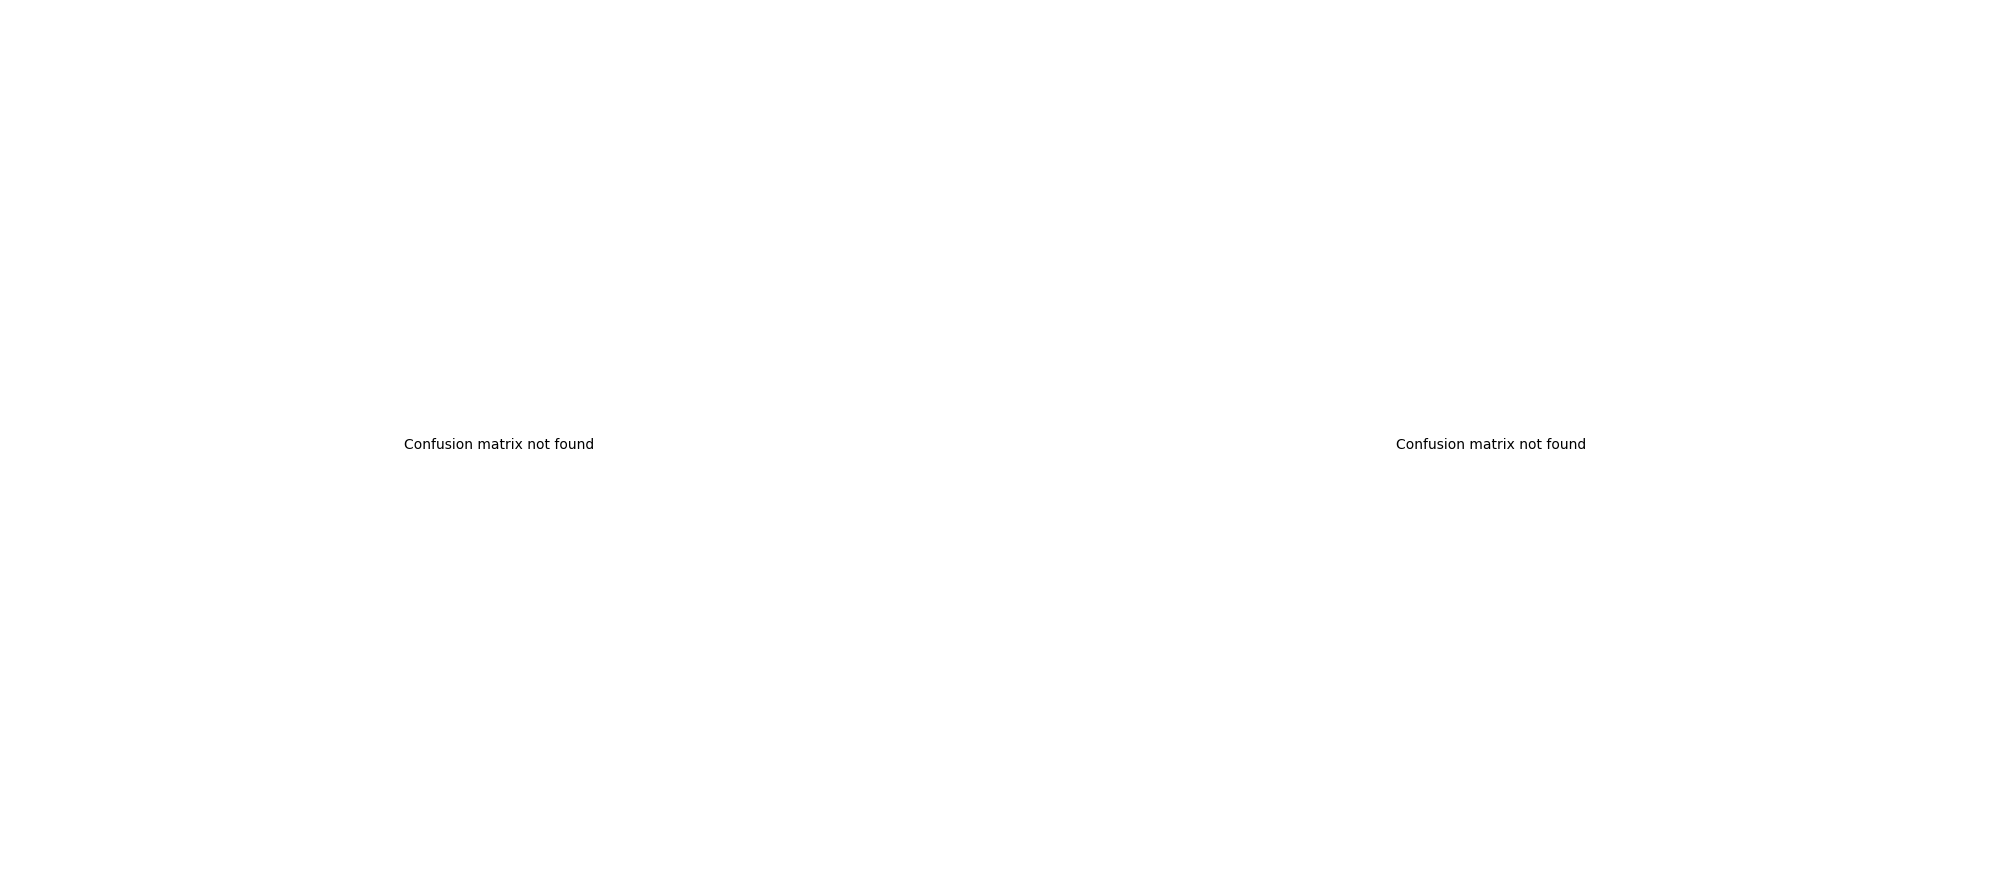

Saved combined confusion matrix to:
/content/drive/MyDrive/thesis-maltese-dataset/eval_confusion_matrices_side_by_side.png


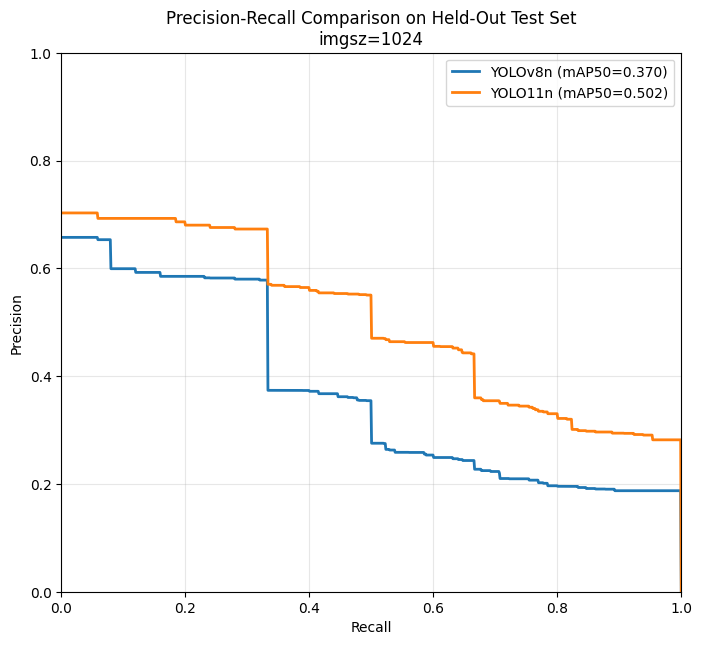

Saved PR comparison to:
/content/drive/MyDrive/thesis-maltese-dataset/eval_pr_curve_comparison.png


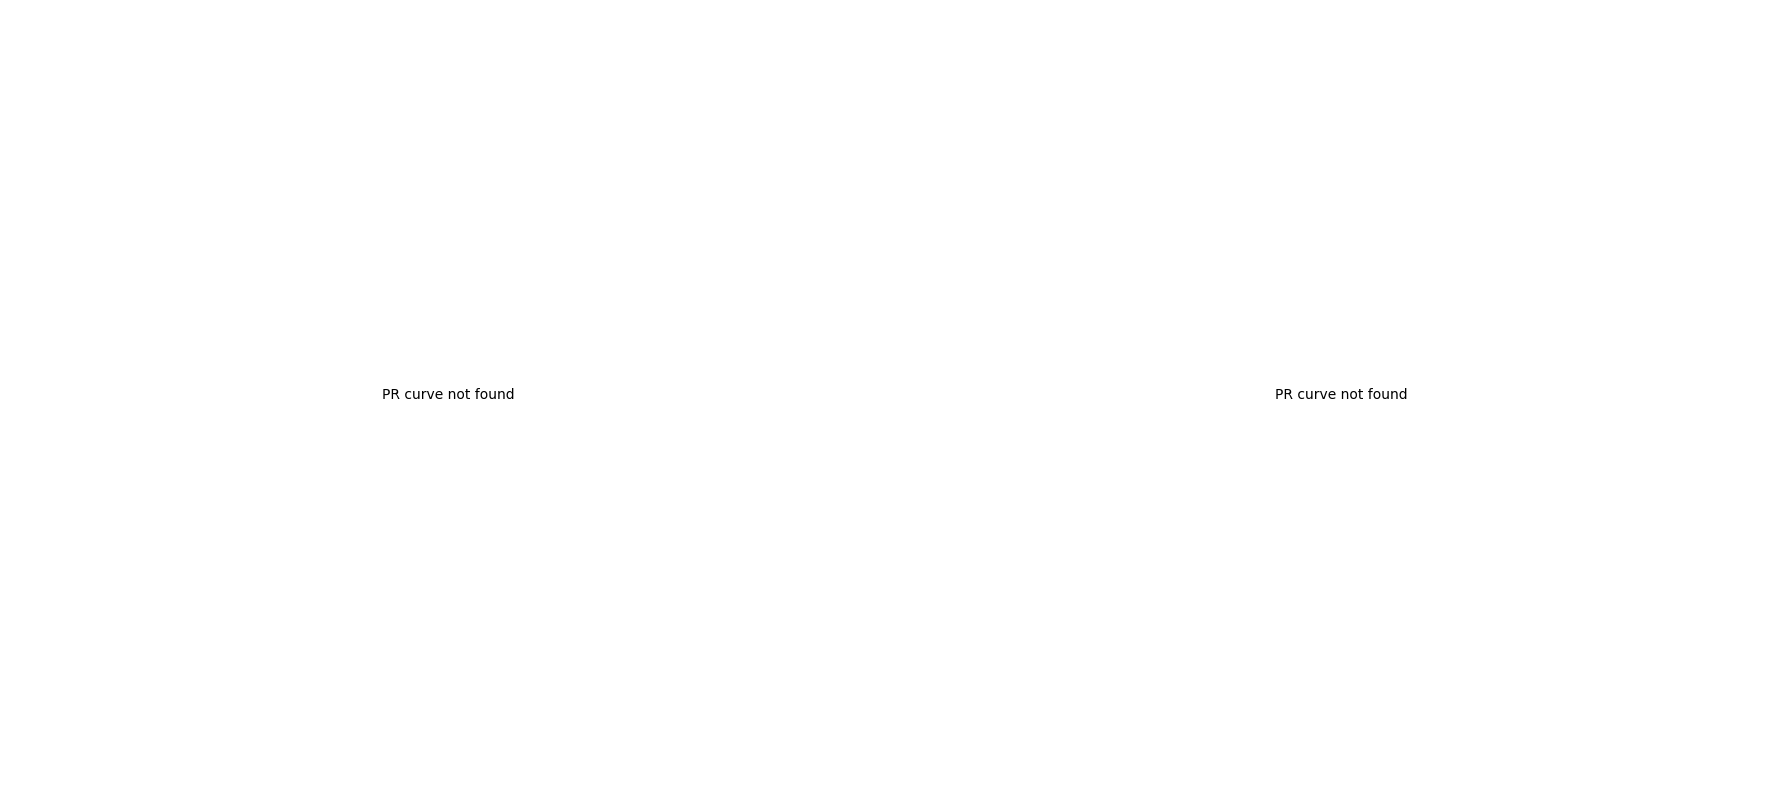


Individual PR curve source files:
  YOLOv8n: None
  YOLO11n: None

Classes with zero test-set instances (13/26):
['bonds', 'citadel_inc', 'fabalcasa', 'forestals', 'hotpoint', 'kitkat', 'lotto', 'nso', 'poltronesofa', 'pavi_pama', 'scratchiz', 'super5plus', 'wasteserv']

Saved per-class comparison to:
/content/drive/MyDrive/thesis-maltese-dataset/eval_per_class_comparison.csv


,yolov8n_P,yolov8n_R,yolov8n_mAP50,yolov8n_mAP50-95,yolo11n_P,yolo11n_R,yolo11n_mAP50,yolo11n_mAP50-95,test_instances
class,,,,,,,,,
atlas_inc,0.855,1.000,0.995,0.435,0.778,1.000,0.995,0.514,3
bnf_bank,0.887,0.500,0.500,0.450,0.429,0.500,0.506,0.450,2
bov,0.655,0.523,0.610,0.301,0.823,0.431,0.667,0.371,65
cisk,0.496,0.080,0.124,0.041,0.363,0.240,0.194,0.044,25
go,0.652,0.333,0.335,0.302,0.766,0.333,0.335,0.268,3
greens,0.000,0.000,0.015,0.007,0.000,0.000,0.018,0.009,2
izibet,0.000,0.000,0.038,0.014,0.000,0.000,0.066,0.031,18
lidl,0.193,0.611,0.284,0.263,0.870,1.000,0.995,0.995,2
lotto_quanterno,0.809,1.000,0.995,0.862,0.776,1.000,0.995,0.830,3



--- Background-Confusion Rates ---
atlas_inc            instances=  3 | v8n=0% | v11n=0%
bnf_bank             instances=  2 | v8n=50% | v11n=0%
bov                  instances= 65 | v8n=43% | v11n=34%
cisk                 instances= 25 | v8n=88% | v11n=48%
go                   instances=  3 | v8n=67% | v11n=67%
greens               instances=  2 | v8n=50% | v11n=100%
izibet               instances= 18 | v8n=78% | v11n=61%
lidl                 instances=  2 | v8n=50% | v11n=0%
lotto_quanterno      instances=  3 | v8n=0% | v11n=0%
national_loterry     instances=  3 | v8n=67% | v11n=33%
super5               instances=  3 | v8n=33% | v11n=0%
virtue_ferries       instances=  2 | v8n=100% | v11n=100%
visit_malta          instances= 17 | v8n=100% | v11n=76%

Saved background-confusion table to:
/content/drive/MyDrive/thesis-maltese-dataset/eval_background_confusion_rates.csv

EVALUATION COMPLETE

Evaluation resolution:
  imgsz = 1024

Generated thesis/evaluation files:
  /content/drive/MyDriv

In [ ]:
# ============================================================================
# Standalone YOLO Evaluation & Comparison
# Run this cell first in a fresh Google Colab session.
#
# Provides everything needed to compare the fine-tuned YOLOv8n and YOLO11n
# models without rerunning the dataset-building or training cells.
#
# Safe to run multiple times.
# ============================================================================

import os
import glob

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import torch

from google.colab import drive


# 1. Environment setup
drive.mount("/content/drive")

print("GPU available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


# Install Ultralytics if needed.
!pip install -q ultralytics albumentations

from ultralytics import YOLO


# 2. Configuration
DATASET_DRIVE_DIR = "/content/drive/MyDrive/thesis-maltese-dataset"
FINETUNE_DIR = f"{DATASET_DRIVE_DIR}/finetune_checkpoints"

OUTPUT_DIR = "/content/yolo_dataset_malta_mixed_v2"
DATASET_YAML = f"{OUTPUT_DIR}/malta_brands.yaml"

# Use the same evaluation resolution for both models.
# Set to 640 only if 640 is the resolution you intend to report.
EVAL_IMGSZ = 1024
EVAL_BATCH_SIZE = 16

RUNS_DIR = "runs/detect/finetune"

MODEL_PATHS = {
    "YOLOv8n": f"{FINETUNE_DIR}/yolov8n_finetune_malta_mixed_v2_final.pt",
    "YOLO11n": f"{FINETUNE_DIR}/yolo11n_finetune_malta_mixed_v2_final.pt",
}

BRANDS = [
    "atlas_inc",
    "bnf_bank",
    "bonds",
    "bov",
    "cisk",
    "citadel_inc",
    "fabalcasa",
    "forestals",
    "go",
    "greens",
    "hotpoint",
    "izibet",
    "kitkat",
    "lidl",
    "lotto",
    "lotto_quanterno",
    "national_loterry",
    "nso",
    "poltronesofa",
    "pavi_pama",
    "scratchiz",
    "super5",
    "super5plus",
    "virtue_ferries",
    "visit_malta",
    "wasteserv",
]

BRAND2IDX = {brand: i for i, brand in enumerate(BRANDS)}


# 3. Restore dataset if necessary
if not os.path.exists(OUTPUT_DIR):
    zip_path = f"{DATASET_DRIVE_DIR}/yolo_dataset_malta_mixed_v2.zip"

    print("Local dataset not found.")
    print("Restoring dataset from Drive backup...")

    if not os.path.exists(zip_path):
        raise FileNotFoundError(
            f"Dataset backup not found at:\n{zip_path}\n\n"
            "Rerun the original dataset-building cells instead."
        )

    !unzip -q "{zip_path}" -d /content
    print("Dataset restored successfully.")

else:
    print("Dataset already present locally.")


# 4. Sanity checks
print("\n--- Sanity Check ---")
print(f"Dataset Drive directory : {DATASET_DRIVE_DIR}")
print(f"Fine-tune directory     : {FINETUNE_DIR}")
print(f"Dataset YAML            : {DATASET_YAML}")
print(f"YAML exists             : {os.path.exists(DATASET_YAML)}")

for model_name, model_path in MODEL_PATHS.items():
    print(f"{model_name} checkpoint exists : {os.path.exists(model_path)}")

if not os.path.exists(DATASET_YAML):
    raise FileNotFoundError(f"Dataset YAML not found: {DATASET_YAML}")

for model_name, model_path in MODEL_PATHS.items():
    if not os.path.exists(model_path):
        raise FileNotFoundError(
            f"{model_name} checkpoint not found: {model_path}"
        )


# 5. Helper functions
def latest_plot(run_name_prefix, filename):
    """Return the most recently generated plot matching a run prefix."""
    pattern = f"{RUNS_DIR}/{run_name_prefix}*/{filename}"

    matches = sorted(
        glob.glob(pattern),
        key=os.path.getmtime,
    )

    return matches[-1] if matches else None


def get_pr_curve(results):
    """
    Extract the mean all-class Precision-Recall curve from an Ultralytics
    validation results object.

    Handles Ultralytics versions where curves_results tuples differ slightly
    in structure.
    """
    curves = getattr(results, "curves_results", None)
    names = getattr(results, "curves", None)

    if curves is None or names is None:
        raise RuntimeError(
            "This Ultralytics version does not expose curves_results."
        )

    for curve_tuple, name in zip(curves, names):
        if "Precision-Recall" not in name:
            continue

        recall = np.asarray(curve_tuple[0])
        precision = np.asarray(curve_tuple[1])

        # Average across classes if per-class curves are returned.
        if precision.ndim > 1:
            precision = precision.mean(axis=0)

        return recall, precision

    raise RuntimeError("Precision-Recall curve not found in curves_results.")


def per_class_df(results, model_name):
    """Create a per-class metric DataFrame from Ultralytics results."""
    box = results.box
    rows = []

    for i, cls_idx in enumerate(box.ap_class_index):
        cls_idx = int(cls_idx)

        rows.append(
            {
                "class": BRANDS[cls_idx],
                f"{model_name}_P": box.p[i],
                f"{model_name}_R": box.r[i],
                f"{model_name}_mAP50": box.ap50[i],
                f"{model_name}_mAP50-95": box.ap[i],
            }
        )

    return pd.DataFrame(rows).set_index("class")


def count_test_instances(label_dir, num_classes):
    """Count ground-truth object instances for each class in YOLO labels."""
    counts = [0] * num_classes

    for label_path in glob.glob(f"{label_dir}/*.txt"):
        with open(label_path, "r") as file:
            for line in file:
                parts = line.split()

                if not parts:
                    continue

                class_id = int(float(parts[0]))

                if 0 <= class_id < num_classes:
                    counts[class_id] += 1

    return counts


def background_confusion_rates(results, brands):
    """
    Calculate the proportion of ground-truth instances for each class that
    were classified as background (false negatives).

    Ultralytics confusion matrix:
        rows    = predicted classes
        columns = true classes
        final row/column = background
    """
    cm = np.asarray(results.confusion_matrix.matrix)

    num_classes = len(brands)
    background_row = num_classes

    rates = {}

    for class_idx, class_name in enumerate(brands):
        true_instances = cm[:, class_idx].sum()

        if true_instances > 0:
            rates[class_name] = (
                cm[background_row, class_idx] / true_instances
            )

    return rates


# 6. Evaluate both models on the held-out test set
print(
    f"\nEvaluating both models at imgsz={EVAL_IMGSZ}, "
    f"batch={EVAL_BATCH_SIZE}...\n"
)

model8 = YOLO(MODEL_PATHS["YOLOv8n"])
r8 = model8.val(
    data=DATASET_YAML,
    split="test",
    imgsz=EVAL_IMGSZ,
    batch=EVAL_BATCH_SIZE,
    plots=True,
    project=RUNS_DIR,
    name=f"YOLOv8n_COMPARE_{EVAL_IMGSZ}",
)

model11 = YOLO(MODEL_PATHS["YOLO11n"])
r11 = model11.val(
    data=DATASET_YAML,
    split="test",
    imgsz=EVAL_IMGSZ,
    batch=EVAL_BATCH_SIZE,
    plots=True,
    project=RUNS_DIR,
    name=f"YOLO11n_COMPARE_{EVAL_IMGSZ}",
)


# 7. Overall metric comparison
print("\n--- Test-Set Results ---")

print(
    f"YOLOv8n  | "
    f"mAP50: {r8.box.map50:.3f} | "
    f"mAP50-95: {r8.box.map:.3f} | "
    f"P: {r8.box.mp:.3f} | "
    f"R: {r8.box.mr:.3f}"
)

print(
    f"YOLO11n  | "
    f"mAP50: {r11.box.map50:.3f} | "
    f"mAP50-95: {r11.box.map:.3f} | "
    f"P: {r11.box.mp:.3f} | "
    f"R: {r11.box.mr:.3f}"
)


# 8. Side-by-side normalized confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(20, 9))

confusion_specs = [
    (axes[0], "YOLOv8n_COMPARE", "YOLOv8n"),
    (axes[1], "YOLO11n_COMPARE", "YOLO11n"),
]

for ax, run_prefix, title in confusion_specs:
    path = latest_plot(
        run_prefix,
        "confusion_matrix_normalized.png",
    )

    if path:
        ax.imshow(mpimg.imread(path))
        ax.set_title(
            f"{title} — Normalised Confusion Matrix\n"
            f"Held-Out Test Set, imgsz={EVAL_IMGSZ}"
        )
        ax.axis("off")
    else:
        ax.text(
            0.5,
            0.5,
            "Confusion matrix not found",
            ha="center",
            va="center",
        )
        ax.axis("off")

plt.tight_layout()

confusion_output = (
    f"{DATASET_DRIVE_DIR}/eval_confusion_matrices_side_by_side.png"
)

plt.savefig(
    confusion_output,
    dpi=200,
    bbox_inches="tight",
)
plt.show()

print(f"Saved combined confusion matrix to:\n{confusion_output}")


# 9. Overlaid Precision-Recall comparison
try:
    rec8, prec8 = get_pr_curve(r8)
    rec11, prec11 = get_pr_curve(r11)

    plt.figure(figsize=(8, 7))

    plt.plot(
        rec8,
        prec8,
        label=f"YOLOv8n (mAP50={r8.box.map50:.3f})",
        linewidth=2,
    )

    plt.plot(
        rec11,
        prec11,
        label=f"YOLO11n (mAP50={r11.box.map50:.3f})",
        linewidth=2,
    )

    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(
        "Precision-Recall Comparison on Held-Out Test Set\n"
        f"imgsz={EVAL_IMGSZ}"
    )

    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.legend()
    plt.grid(alpha=0.3)

    pr_comparison_output = (
        f"{DATASET_DRIVE_DIR}/eval_pr_curve_comparison.png"
    )

    plt.savefig(
        pr_comparison_output,
        dpi=200,
        bbox_inches="tight",
    )
    plt.show()

    print(f"Saved PR comparison to:\n{pr_comparison_output}")

except RuntimeError as error:
    print(
        "\nCould not generate overlaid PR curves from results object."
    )
    print(f"Reason: {error}")
    print("Using Ultralytics' saved PR curves below instead.")


# ============================================================================
# 10. Ultralytics PR curves side by side
#
# Use the individual source PNGs for thesis Figures 5.1 and 5.2.
# The combined figure is mainly useful for direct comparison.
# ============================================================================

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

pr_curve_paths = {}

pr_specs = [
    (axes[0], "YOLOv8n_COMPARE", "YOLOv8n"),
    (axes[1], "YOLO11n_COMPARE", "YOLO11n"),
]

for ax, run_prefix, title in pr_specs:
    path = latest_plot(run_prefix, "BoxPR_curve.png")
    pr_curve_paths[title] = path

    if path:
        ax.imshow(mpimg.imread(path))
        ax.set_title(f"{title} PR Curve")
        ax.axis("off")
    else:
        ax.text(
            0.5,
            0.5,
            "PR curve not found",
            ha="center",
            va="center",
        )
        ax.axis("off")

plt.tight_layout()

pr_side_by_side_output = (
    f"{DATASET_DRIVE_DIR}/eval_pr_curves_side_by_side.png"
)

plt.savefig(
    pr_side_by_side_output,
    dpi=200,
    bbox_inches="tight",
)
plt.show()

print("\nIndividual PR curve source files:")
for title, path in pr_curve_paths.items():
    print(f"  {title}: {path}")


# 11. Per-class comparison — Table 5.2
df8 = per_class_df(r8, "yolov8n")
df11 = per_class_df(r11, "yolo11n")

comparison = df8.join(df11, how="outer")


# Add ground-truth test-set instance counts.
test_label_dir = f"{OUTPUT_DIR}/labels/test"

test_counts = count_test_instances(
    test_label_dir,
    len(BRANDS),
)

comparison["test_instances"] = [
    test_counts[BRAND2IDX[class_name]]
    for class_name in comparison.index
]


# Identify classes with zero test instances.
present_classes = set(comparison.index)

missing_from_test = [
    brand
    for brand in BRANDS
    if brand not in present_classes
]

print(
    f"\nClasses with zero test-set instances "
    f"({len(missing_from_test)}/{len(BRANDS)}):"
)

print(missing_from_test)


# Save table.
comparison_output = (
    f"{DATASET_DRIVE_DIR}/eval_per_class_comparison.csv"
)

comparison.to_csv(comparison_output)

print(f"\nSaved per-class comparison to:\n{comparison_output}")

display(comparison.round(3))


# 12. Background-confusion rates — Table 5.3
rates8 = background_confusion_rates(r8, BRANDS)
rates11 = background_confusion_rates(r11, BRANDS)

background_rows = []

for class_name in BRANDS:
    # Only include classes represented in the test-set confusion matrix.
    if class_name not in rates8 and class_name not in rates11:
        continue

    background_rows.append(
        {
            "class": class_name,
            "test_instances": test_counts[BRAND2IDX[class_name]],
            "yolov8n_background_rate": rates8.get(
                class_name,
                np.nan,
            ),
            "yolo11n_background_rate": rates11.get(
                class_name,
                np.nan,
            ),
        }
    )

background_comparison = (
    pd.DataFrame(background_rows)
    .set_index("class")
)

background_output = (
    f"{DATASET_DRIVE_DIR}/eval_background_confusion_rates.csv"
)

background_comparison.to_csv(background_output)

print("\n--- Background-Confusion Rates ---")

for class_name, row in background_comparison.iterrows():
    v8 = row["yolov8n_background_rate"]
    v11 = row["yolo11n_background_rate"]

    print(
        f"{class_name:20s} "
        f"instances={int(row['test_instances']):3d} | "
        f"v8n={v8:.0%} | "
        f"v11n={v11:.0%}"
    )

print(f"\nSaved background-confusion table to:\n{background_output}")


# 13. Output summary
print("\n" + "=" * 72)
print("EVALUATION COMPLETE")
print("=" * 72)

print(f"""
Evaluation resolution:
  imgsz = {EVAL_IMGSZ}

Generated thesis/evaluation files:
  {confusion_output}
  {pr_side_by_side_output}
  {comparison_output}
  {background_output}

Individual PR curves:
  YOLOv8n : {pr_curve_paths["YOLOv8n"]}
  YOLO11n : {pr_curve_paths["YOLO11n"]}
""")

### 5.3 Reported comparison at 416 px (Tables 5.1–5.3)
Uses the helpers below:

- `latest_plot` finds the newest Ultralytics plot for a run prefix.
- `get_pr_curve` extracts the mean all-class precision–recall curve.
- `per_class_df` builds per-class P / R / mAP tables.
- `count_test_instances` counts ground-truth boxes per class in a label folder.
- `background_confusion_rates` gives the share of each class's true instances missed as background.

The cell then:

1. Evaluates both checkpoints on the test split at 416 px.
2. Prints overall mAP50, mAP50-95, precision and recall (Table 5.1).
3. Saves side-by-side normalised confusion matrices.
4. Saves overlaid PR curves.
5. Saves side-by-side Ultralytics PR curves.
6. Saves the per-class comparison (Table 5.2) with test-instance counts, and lists the classes absent from test (13 of 26).
7. Saves the background-confusion rates (Table 5.3).

*Result: YOLOv8n mAP50 0.408 · mAP50-95 0.310 · P 0.602 · R 0.301 | YOLO11n mAP50 0.471 · mAP50-95 0.361 · P 0.588 · R 0.469*

> In the saved outputs, `latest_plot` returned `None` (PR curves "not found"). Ultralytics saved these runs under `runs/detect/runs/detect/finetune/…` (see the "Results saved to" lines), while `RUNS_DIR` points to `runs/detect/finetune`, so the glob misses them. The same applies to 5.2.


--- Sanity Check ---
Dataset Drive directory : /content/drive/MyDrive/thesis-maltese-dataset
Fine-tune directory     : /content/drive/MyDrive/thesis-maltese-dataset/finetune_checkpoints
Dataset YAML            : /content/yolo_dataset_malta_mixed_v2/malta_brands.yaml
YAML exists             : True
YOLOv8n checkpoint exists : True
YOLO11n checkpoint exists : True

Evaluating both models at imgsz=416, batch=16...

Ultralytics 8.4.161 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8n summary (fused): 72 layers, 3,010,718 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1879.2±757.5 MB/s, size: 123.0 KB)
val: Scanning /content/yolo_dataset_malta_mixed_v2/labels/test.cache... 46 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 46/46 13.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 1.6it/s 1.9s
                   all         46        148      0.602     

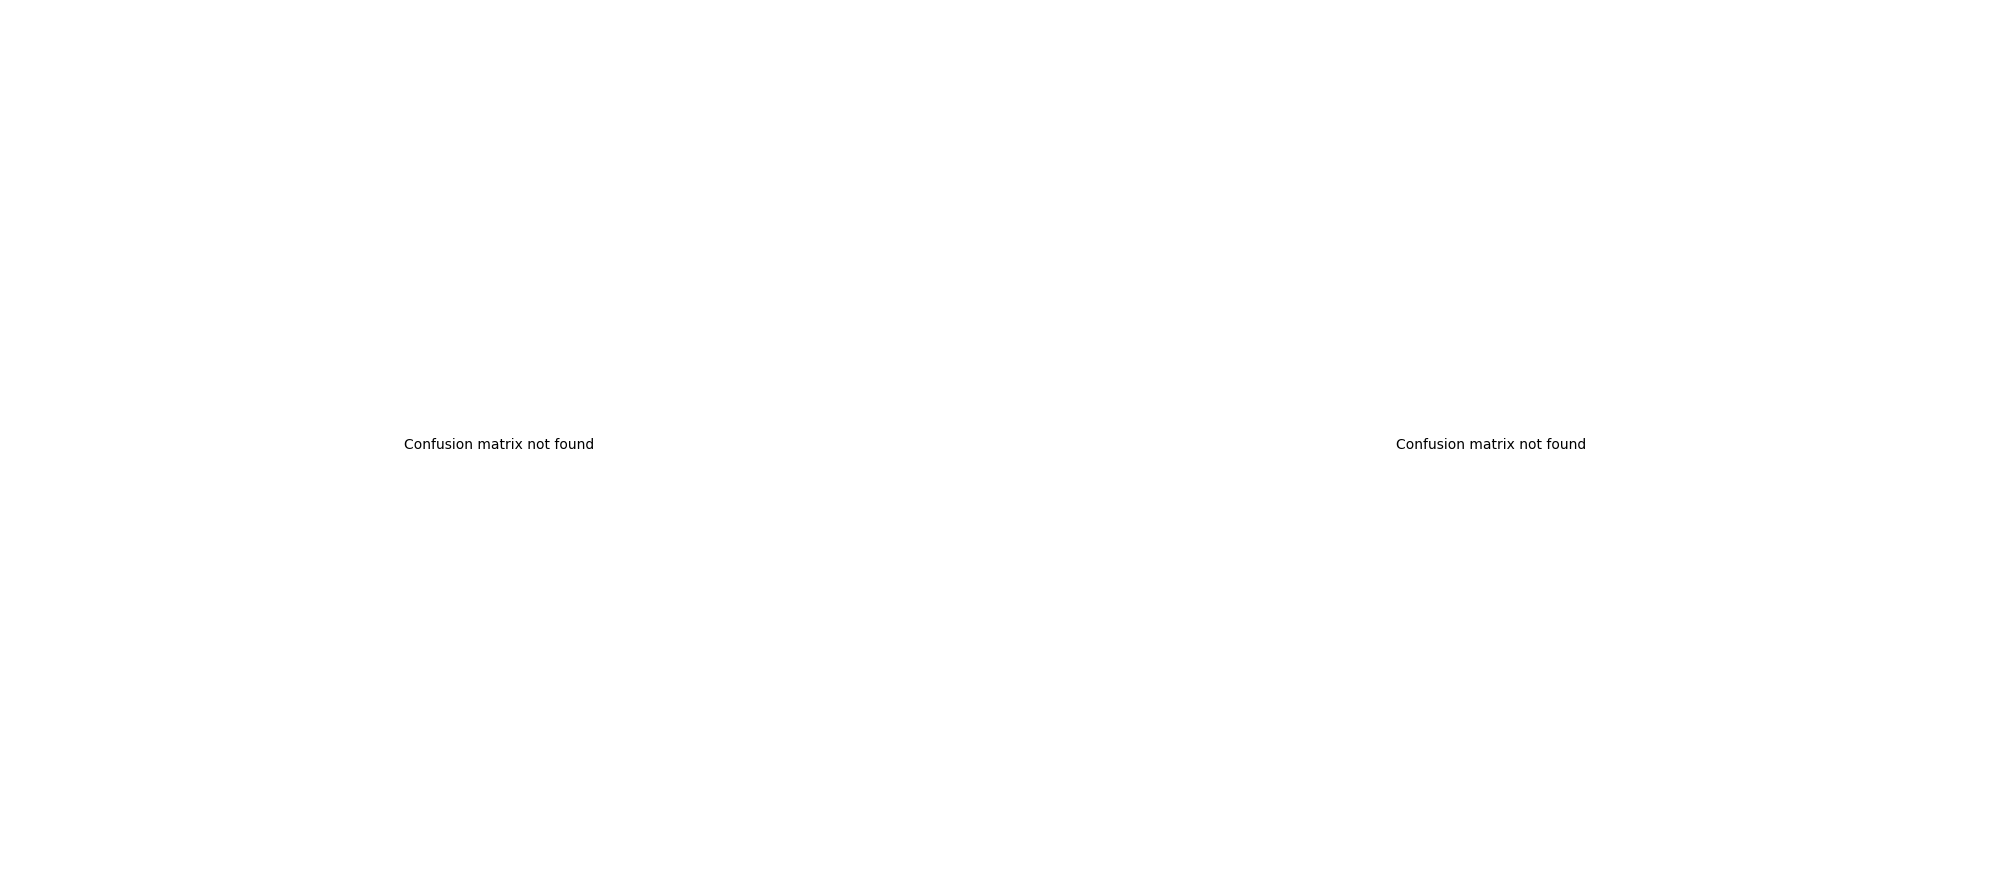

Saved combined confusion matrix to:
/content/drive/MyDrive/thesis-maltese-dataset/eval_confusion_matrices_side_by_side.png


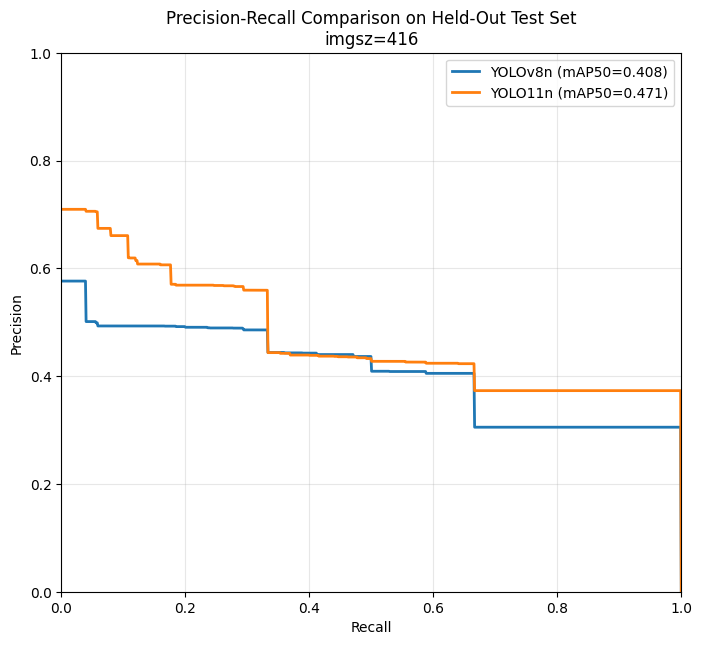

Saved PR comparison to:
/content/drive/MyDrive/thesis-maltese-dataset/eval_pr_curve_comparison.png


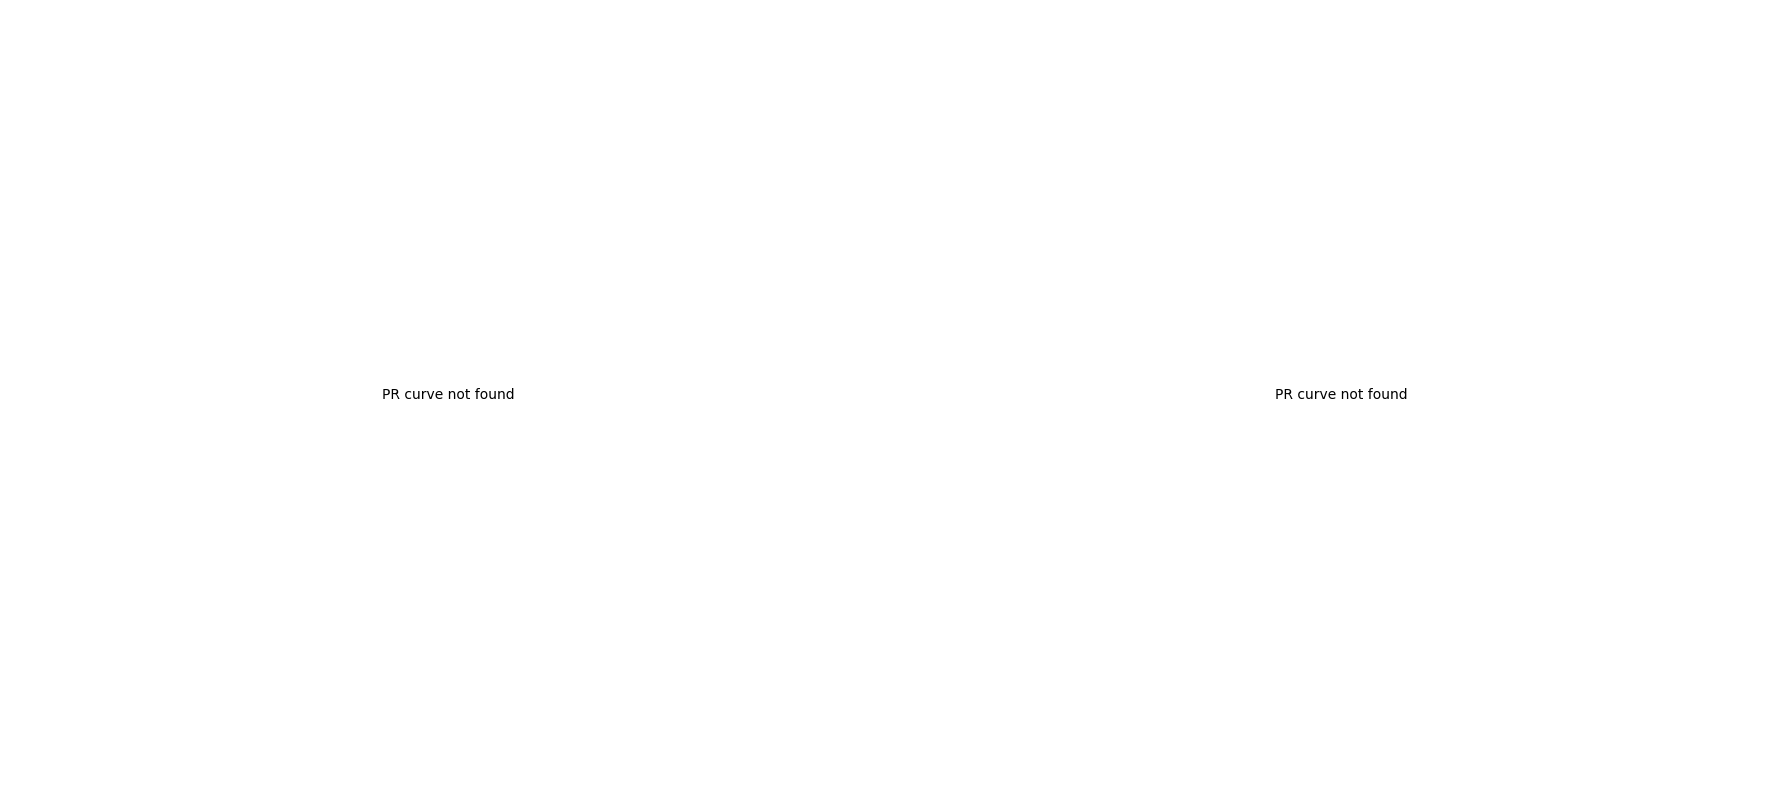


Individual PR curve source files:
  YOLOv8n: None
  YOLO11n: None

Classes with zero test-set instances (13/26):
['bonds', 'citadel_inc', 'fabalcasa', 'forestals', 'hotpoint', 'kitkat', 'lotto', 'nso', 'poltronesofa', 'pavi_pama', 'scratchiz', 'super5plus', 'wasteserv']

Saved per-class comparison to:
/content/drive/MyDrive/thesis-maltese-dataset/eval_per_class_comparison.csv


,yolov8n_P,yolov8n_R,yolov8n_mAP50,yolov8n_mAP50-95,yolo11n_P,yolo11n_R,yolo11n_mAP50,yolo11n_mAP50-95,test_instances
class,,,,,,,,,
atlas_inc,1.000,0.646,0.995,0.597,0.770,1.000,0.995,0.813,3
bnf_bank,0.584,0.500,0.828,0.679,0.762,1.000,0.995,0.755,2
bov,0.033,0.077,0.009,0.004,0.132,0.246,0.125,0.063,65
cisk,0.501,0.040,0.041,0.005,0.128,0.080,0.039,0.015,25
go,1.000,0.000,0.048,0.029,0.849,0.333,0.335,0.234,3
greens,1.000,0.000,0.011,0.004,1.000,0.000,0.033,0.020,2
izibet,0.000,0.000,0.005,0.001,0.000,0.000,0.014,0.005,18
lidl,0.767,1.000,0.995,0.995,0.695,1.000,0.995,0.896,2
lotto_quanterno,0.566,0.333,0.731,0.493,0.476,0.667,0.665,0.500,3



--- Background-Confusion Rates ---
atlas_inc            instances=  3 | v8n=0% | v11n=0%
bnf_bank             instances=  2 | v8n=50% | v11n=0%
bov                  instances= 65 | v8n=97% | v11n=86%
cisk                 instances= 25 | v8n=96% | v11n=92%
go                   instances=  3 | v8n=100% | v11n=100%
greens               instances=  2 | v8n=100% | v11n=100%
izibet               instances= 18 | v8n=100% | v11n=89%
lidl                 instances=  2 | v8n=0% | v11n=0%
lotto_quanterno      instances=  3 | v8n=33% | v11n=67%
national_loterry     instances=  3 | v8n=33% | v11n=0%
super5               instances=  3 | v8n=67% | v11n=33%
virtue_ferries       instances=  2 | v8n=100% | v11n=100%
visit_malta          instances= 17 | v8n=94% | v11n=94%

Saved background-confusion table to:
/content/drive/MyDrive/thesis-maltese-dataset/eval_background_confusion_rates.csv

EVALUATION COMPLETE

Evaluation resolution:
  imgsz = 416

Generated thesis/evaluation files:
  /content/drive/MyD

In [ ]:
# Configuration
# Paths, BRANDS and BRAND2IDX come from Sections 1-2. The evaluation
# resolution is passed to compare_models() below.

EVAL_IMGSZ = 416
EVAL_BATCH_SIZE = 16

RUNS_DIR = "runs/detect/finetune"
OUTPUT_DIR = OUTPUT_DIR_MIXED_V2
DATASET_YAML = DATASET_YAML_MIXED_V2

MODEL_PATHS = {
    "YOLOv8n": f"{FINETUNE_DIR}/yolov8n_finetune_malta_mixed_v2_final.pt",
    "YOLO11n": f"{FINETUNE_DIR}/yolo11n_finetune_malta_mixed_v2_final.pt",
}


# Sanity checks
print("\n--- Sanity Check ---")
print(f"Dataset Drive directory : {DATASET_DRIVE_DIR}")
print(f"Fine-tune directory     : {FINETUNE_DIR}")
print(f"Dataset YAML            : {DATASET_YAML}")
print(f"YAML exists             : {os.path.exists(DATASET_YAML)}")

for model_name, model_path in MODEL_PATHS.items():
    print(f"{model_name} checkpoint exists : {os.path.exists(model_path)}")

if not os.path.exists(DATASET_YAML):
    raise FileNotFoundError(f"Dataset YAML not found: {DATASET_YAML}")

for model_name, model_path in MODEL_PATHS.items():
    if not os.path.exists(model_path):
        raise FileNotFoundError(
            f"{model_name} checkpoint not found: {model_path}"
        )


# Helper functions
def latest_plot(run_name_prefix, filename):
    """Return the most recently generated plot matching a run prefix."""
    pattern = f"{RUNS_DIR}/{run_name_prefix}*/{filename}"

    matches = sorted(
        glob.glob(pattern),
        key=os.path.getmtime,
    )

    return matches[-1] if matches else None


def get_pr_curve(results):
    """
    Extract the mean all-class Precision-Recall curve from an Ultralytics
    validation results object.

    Handles Ultralytics versions where curves_results tuples differ slightly
    in structure.
    """
    curves = getattr(results, "curves_results", None)
    names = getattr(results, "curves", None)

    if curves is None or names is None:
        raise RuntimeError(
            "This Ultralytics version does not expose curves_results."
        )

    for curve_tuple, name in zip(curves, names):
        if "Precision-Recall" not in name:
            continue

        recall = np.asarray(curve_tuple[0])
        precision = np.asarray(curve_tuple[1])

        # Average across classes if per-class curves are returned.
        if precision.ndim > 1:
            precision = precision.mean(axis=0)

        return recall, precision

    raise RuntimeError("Precision-Recall curve not found in curves_results.")


def per_class_df(results, model_name):
    """Create a per-class metric DataFrame from Ultralytics results."""
    box = results.box
    rows = []

    for i, cls_idx in enumerate(box.ap_class_index):
        cls_idx = int(cls_idx)

        rows.append(
            {
                "class": BRANDS[cls_idx],
                f"{model_name}_P": box.p[i],
                f"{model_name}_R": box.r[i],
                f"{model_name}_mAP50": box.ap50[i],
                f"{model_name}_mAP50-95": box.ap[i],
            }
        )

    return pd.DataFrame(rows).set_index("class")


def count_test_instances(label_dir, num_classes):
    """Count ground-truth object instances for each class in YOLO labels."""
    counts = [0] * num_classes

    for label_path in glob.glob(f"{label_dir}/*.txt"):
        with open(label_path, "r") as file:
            for line in file:
                parts = line.split()

                if not parts:
                    continue

                class_id = int(float(parts[0]))

                if 0 <= class_id < num_classes:
                    counts[class_id] += 1

    return counts


def background_confusion_rates(results, brands):
    """
    Calculate the proportion of ground-truth instances for each class that
    were classified as background (false negatives).

    Ultralytics confusion matrix:
        rows    = predicted classes
        columns = true classes
        final row/column = background
    """
    cm = np.asarray(results.confusion_matrix.matrix)

    num_classes = len(brands)
    background_row = num_classes

    rates = {}

    for class_idx, class_name in enumerate(brands):
        true_instances = cm[:, class_idx].sum()

        if true_instances > 0:
            rates[class_name] = (
                cm[background_row, class_idx] / true_instances
            )

    return rates


# ============================================================================
# 6. Evaluate both models on the held-out test set
# ============================================================================

print(
    f"\nEvaluating both models at imgsz={EVAL_IMGSZ}, "
    f"batch={EVAL_BATCH_SIZE}...\n"
)

model8 = YOLO(MODEL_PATHS["YOLOv8n"])
r8 = model8.val(
    data=DATASET_YAML,
    split="test",
    imgsz=EVAL_IMGSZ,
    batch=EVAL_BATCH_SIZE,
    plots=True,
    project=RUNS_DIR,
    name=f"YOLOv8n_COMPARE_{EVAL_IMGSZ}",
)

model11 = YOLO(MODEL_PATHS["YOLO11n"])
r11 = model11.val(
    data=DATASET_YAML,
    split="test",
    imgsz=EVAL_IMGSZ,
    batch=EVAL_BATCH_SIZE,
    plots=True,
    project=RUNS_DIR,
    name=f"YOLO11n_COMPARE_{EVAL_IMGSZ}",
)


# Overall metric comparison
print("\n--- Test-Set Results ---")

print(
    f"YOLOv8n  | "
    f"mAP50: {r8.box.map50:.3f} | "
    f"mAP50-95: {r8.box.map:.3f} | "
    f"P: {r8.box.mp:.3f} | "
    f"R: {r8.box.mr:.3f}"
)

print(
    f"YOLO11n  | "
    f"mAP50: {r11.box.map50:.3f} | "
    f"mAP50-95: {r11.box.map:.3f} | "
    f"P: {r11.box.mp:.3f} | "
    f"R: {r11.box.mr:.3f}"
)


# Side-by-side normalized confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(20, 9))

confusion_specs = [
    (axes[0], "YOLOv8n_COMPARE", "YOLOv8n"),
    (axes[1], "YOLO11n_COMPARE", "YOLO11n"),
]

for ax, run_prefix, title in confusion_specs:
    path = latest_plot(
        run_prefix,
        "confusion_matrix_normalized.png",
    )

    if path:
        ax.imshow(mpimg.imread(path))
        ax.set_title(
            f"{title} — Normalised Confusion Matrix\n"
            f"Held-Out Test Set, imgsz={EVAL_IMGSZ}"
        )
        ax.axis("off")
    else:
        ax.text(
            0.5,
            0.5,
            "Confusion matrix not found",
            ha="center",
            va="center",
        )
        ax.axis("off")

plt.tight_layout()

confusion_output = (
    f"{DATASET_DRIVE_DIR}/eval_confusion_matrices_side_by_side.png"
)

plt.savefig(
    confusion_output,
    dpi=200,
    bbox_inches="tight",
)
plt.show()

print(f"Saved combined confusion matrix to:\n{confusion_output}")


# Overlaid Precision-Recall comparison
try:
    rec8, prec8 = get_pr_curve(r8)
    rec11, prec11 = get_pr_curve(r11)

    plt.figure(figsize=(8, 7))

    plt.plot(
        rec8,
        prec8,
        label=f"YOLOv8n (mAP50={r8.box.map50:.3f})",
        linewidth=2,
    )

    plt.plot(
        rec11,
        prec11,
        label=f"YOLO11n (mAP50={r11.box.map50:.3f})",
        linewidth=2,
    )

    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(
        "Precision-Recall Comparison on Held-Out Test Set\n"
        f"imgsz={EVAL_IMGSZ}"
    )

    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.legend()
    plt.grid(alpha=0.3)

    pr_comparison_output = (
        f"{DATASET_DRIVE_DIR}/eval_pr_curve_comparison.png"
    )

    plt.savefig(
        pr_comparison_output,
        dpi=200,
        bbox_inches="tight",
    )
    plt.show()

    print(f"Saved PR comparison to:\n{pr_comparison_output}")

except RuntimeError as error:
    print(
        "\nCould not generate overlaid PR curves from results object."
    )
    print(f"Reason: {error}")
    print("Using Ultralytics' saved PR curves below instead.")


# ============================================================================
# Ultralytics PR curves side by side
#
# Use the individual source PNGs for thesis Figures 5.1 and 5.2.
# The combined figure is mainly useful for direct comparison.
# ============================================================================

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

pr_curve_paths = {}

pr_specs = [
    (axes[0], "YOLOv8n_COMPARE", "YOLOv8n"),
    (axes[1], "YOLO11n_COMPARE", "YOLO11n"),
]

for ax, run_prefix, title in pr_specs:
    path = latest_plot(run_prefix, "BoxPR_curve.png")
    pr_curve_paths[title] = path

    if path:
        ax.imshow(mpimg.imread(path))
        ax.set_title(f"{title} PR Curve")
        ax.axis("off")
    else:
        ax.text(
            0.5,
            0.5,
            "PR curve not found",
            ha="center",
            va="center",
        )
        ax.axis("off")

plt.tight_layout()

pr_side_by_side_output = (
    f"{DATASET_DRIVE_DIR}/eval_pr_curves_side_by_side.png"
)

plt.savefig(
    pr_side_by_side_output,
    dpi=200,
    bbox_inches="tight",
)
plt.show()

print("\nIndividual PR curve source files:")
for title, path in pr_curve_paths.items():
    print(f"  {title}: {path}")


# Per-class comparison — Table 5.2
df8 = per_class_df(r8, "yolov8n")
df11 = per_class_df(r11, "yolo11n")

comparison = df8.join(df11, how="outer")


# Add ground-truth test-set instance counts.
test_label_dir = f"{OUTPUT_DIR}/labels/test"

test_counts = count_test_instances(
    test_label_dir,
    len(BRANDS),
)

comparison["test_instances"] = [
    test_counts[BRAND2IDX[class_name]]
    for class_name in comparison.index
]


# Identify classes with zero test instances.
present_classes = set(comparison.index)

missing_from_test = [
    brand
    for brand in BRANDS
    if brand not in present_classes
]

print(
    f"\nClasses with zero test-set instances "
    f"({len(missing_from_test)}/{len(BRANDS)}):"
)

print(missing_from_test)


# Save table.
comparison_output = (
    f"{DATASET_DRIVE_DIR}/eval_per_class_comparison.csv"
)

comparison.to_csv(comparison_output)

print(f"\nSaved per-class comparison to:\n{comparison_output}")

display(comparison.round(3))


# Background-confusion rates — Table 5.3
rates8 = background_confusion_rates(r8, BRANDS)
rates11 = background_confusion_rates(r11, BRANDS)

background_rows = []

for class_name in BRANDS:
    # Only include classes represented in the test-set confusion matrix.
    if class_name not in rates8 and class_name not in rates11:
        continue

    background_rows.append(
        {
            "class": class_name,
            "test_instances": test_counts[BRAND2IDX[class_name]],
            "yolov8n_background_rate": rates8.get(
                class_name,
                np.nan,
            ),
            "yolo11n_background_rate": rates11.get(
                class_name,
                np.nan,
            ),
        }
    )

background_comparison = (
    pd.DataFrame(background_rows)
    .set_index("class")
)

background_output = (
    f"{DATASET_DRIVE_DIR}/eval_background_confusion_rates.csv"
)

background_comparison.to_csv(background_output)

print("\n--- Background-Confusion Rates ---")

for class_name, row in background_comparison.iterrows():
    v8 = row["yolov8n_background_rate"]
    v11 = row["yolo11n_background_rate"]

    print(
        f"{class_name:20s} "
        f"instances={int(row['test_instances']):3d} | "
        f"v8n={v8:.0%} | "
        f"v11n={v11:.0%}"
    )

print(f"\nSaved background-confusion table to:\n{background_output}")


# Output summary
print("\n" + "=" * 72)
print("EVALUATION COMPLETE")
print("=" * 72)

print(f"""
Evaluation resolution:
  imgsz = {EVAL_IMGSZ}

Generated thesis/evaluation files:
  {confusion_output}
  {pr_side_by_side_output}
  {comparison_output}
  {background_output}

Individual PR curves:
  YOLOv8n : {pr_curve_paths["YOLOv8n"]}
  YOLO11n : {pr_curve_paths["YOLO11n"]}
""")

### 5.4 Exact confusion-matrix export
Writes the raw and normalised confusion matrices for `r8` / `r11` (from 5.3, i.e. 416 px) to CSV, straight from the Ultralytics results rather than read off the PNGs. Rows are predicted class, columns true class, and the last row/column is background. Normalisation matches Ultralytics: each true-class column sums to 1.

In [ ]:
# ============================================================================
# Export exact confusion-matrix values
# No reading/interpreting values from PNG images.
#
# Rows    = Predicted class
# Columns = True class
# Last row/column = Background
# ============================================================================

CLASS_NAMES = BRANDS + ["background"]


def export_confusion_matrix(results, model_name, output_dir):
    # Exact raw confusion-matrix counts from Ultralytics
    cm = np.asarray(results.confusion_matrix.matrix).copy()

    # Raw counts
    raw_df = pd.DataFrame(
        cm,
        index=CLASS_NAMES,
        columns=CLASS_NAMES,
    )

    raw_df.index.name = "Predicted"
    raw_df.columns.name = "True"

    # -------------------------
    # Normalized matrix
    # Same normalization used by Ultralytics:
    # each TRUE-class column sums to 1.
    # -------------------------
    column_totals = cm.sum(axis=0, keepdims=True)

    norm_cm = np.divide(
        cm,
        column_totals,
        out=np.zeros_like(cm, dtype=float),
        where=column_totals != 0,
    )

    norm_df = pd.DataFrame(
        norm_cm,
        index=CLASS_NAMES,
        columns=CLASS_NAMES,
    )

    norm_df.index.name = "Predicted"
    norm_df.columns.name = "True"

    # Save CSV files
    raw_path = os.path.join(
        output_dir,
        f"{model_name}_confusion_matrix_raw.csv",
    )

    norm_path = os.path.join(
        output_dir,
        f"{model_name}_confusion_matrix_normalized.csv",
    )

    raw_df.to_csv(raw_path)
    norm_df.to_csv(norm_path)

    print(f"\n{'=' * 70}")
    print(model_name)
    print("=" * 70)

    print("\nRAW CONFUSION MATRIX:")
    display(raw_df)

    print("\nNORMALIZED CONFUSION MATRIX:")
    display(norm_df.round(4))

    print("\nSaved:")
    print(raw_path)
    print(norm_path)

    return raw_df, norm_df


# YOLOv8n
cm8_raw, cm8_norm = export_confusion_matrix(
    r8,
    "YOLOv8n",
    DATASET_DRIVE_DIR,
)

# YOLO11n
cm11_raw, cm11_norm = export_confusion_matrix(
    r11,
    "YOLO11n",
    DATASET_DRIVE_DIR,
)


YOLOv8n

RAW CONFUSION MATRIX:


True,atlas_inc,bnf_bank,bonds,bov,cisk,citadel_inc,fabalcasa,forestals,go,greens,...,nso,poltronesofa,pavi_pama,scratchiz,super5,super5plus,virtue_ferries,visit_malta,wasteserv,background
Predicted,,,,,,,,,,,,,,,,,,,,,
atlas_inc,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
bnf_bank,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
bonds,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
bov,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,84.0
cisk,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
citadel_inc,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
fabalcasa,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
forestals,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
go,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0



NORMALIZED CONFUSION MATRIX:


True,atlas_inc,bnf_bank,bonds,bov,cisk,citadel_inc,fabalcasa,forestals,go,greens,...,nso,poltronesofa,pavi_pama,scratchiz,super5,super5plus,virtue_ferries,visit_malta,wasteserv,background
Predicted,,,,,,,,,,,,,,,,,,,,,
atlas_inc,0.0,0.0,0.0,0.0000,0.00,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0000,0.0,0.0,0.0000,0.0,0.0106
bnf_bank,0.0,0.5,0.0,0.0000,0.00,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0000,0.0,0.0,0.0000,0.0,0.0000
bonds,0.0,0.0,0.0,0.0000,0.00,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0000,0.0,0.0,0.0000,0.0,0.0000
bov,0.0,0.0,0.0,0.0308,0.00,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0000,0.0,0.0,0.0588,0.0,0.8936
cisk,0.0,0.0,0.0,0.0000,0.04,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0000,0.0,0.0,0.0000,0.0,0.0000
citadel_inc,1.0,0.0,0.0,0.0000,0.00,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0000,0.0,0.0,0.0000,0.0,0.0000
fabalcasa,0.0,0.0,0.0,0.0000,0.00,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0000,0.0,0.0,0.0000,0.0,0.0000
forestals,0.0,0.0,0.0,0.0000,0.00,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0000,0.0,0.0,0.0000,0.0,0.0106
go,0.0,0.0,0.0,0.0000,0.00,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0000,0.0,0.0,0.0000,0.0,0.0000



Saved:
/content/drive/MyDrive/thesis-maltese-dataset/YOLOv8n_confusion_matrix_raw.csv
/content/drive/MyDrive/thesis-maltese-dataset/YOLOv8n_confusion_matrix_normalized.csv

YOLO11n

RAW CONFUSION MATRIX:


True,atlas_inc,bnf_bank,bonds,bov,cisk,citadel_inc,fabalcasa,forestals,go,greens,...,nso,poltronesofa,pavi_pama,scratchiz,super5,super5plus,virtue_ferries,visit_malta,wasteserv,background
Predicted,,,,,,,,,,,,,,,,,,,,,
atlas_inc,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
bnf_bank,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
bonds,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
bov,0.0,0.0,0.0,9.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,38.0
cisk,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0
citadel_inc,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
fabalcasa,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
forestals,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
go,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0



NORMALIZED CONFUSION MATRIX:


True,atlas_inc,bnf_bank,bonds,bov,cisk,citadel_inc,fabalcasa,forestals,go,greens,...,nso,poltronesofa,pavi_pama,scratchiz,super5,super5plus,virtue_ferries,visit_malta,wasteserv,background
Predicted,,,,,,,,,,,,,,,,,,,,,
atlas_inc,1.0,0.0,0.0,0.0000,0.00,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0000,0.0,0.0,0.0000,0.0,0.0000
bnf_bank,0.0,1.0,0.0,0.0000,0.00,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0000,0.0,0.0,0.0000,0.0,0.0000
bonds,0.0,0.0,0.0,0.0000,0.00,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0000,0.0,0.0,0.0000,0.0,0.0000
bov,0.0,0.0,0.0,0.1385,0.00,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0000,0.0,0.0,0.0000,0.0,0.8261
cisk,0.0,0.0,0.0,0.0000,0.08,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0000,0.0,0.0,0.0000,0.0,0.1087
citadel_inc,0.0,0.0,0.0,0.0000,0.00,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0000,0.0,0.0,0.0000,0.0,0.0000
fabalcasa,0.0,0.0,0.0,0.0000,0.00,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0000,0.0,0.0,0.0000,0.0,0.0000
forestals,0.0,0.0,0.0,0.0000,0.00,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0000,0.0,0.0,0.0000,0.0,0.0000
go,0.0,0.0,0.0,0.0000,0.00,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0000,0.0,0.0,0.0000,0.0,0.0000



Saved:
/content/drive/MyDrive/thesis-maltese-dataset/YOLO11n_confusion_matrix_raw.csv
/content/drive/MyDrive/thesis-maltese-dataset/YOLO11n_confusion_matrix_normalized.csv


### 5.5 Confusion-matrix summary per class
For each class present in test: true positives, misses to background (`FN_background`), confusions with another brand (`FN_wrong_class`), and the corresponding rates. Saved per model and as a combined v8/v11 table.

In [ ]:
# ============================================================================
# Thesis-friendly confusion-matrix summary
#
# TP             = correct detections
# FN_background  = true objects missed as background
# FN_wrong_class = true objects detected as another brand
# Background %   = proportion of true instances missed as background
# ============================================================================

def confusion_summary(results, model_name):
    cm = np.asarray(results.confusion_matrix.matrix)
    nc = len(BRANDS)

    rows = []

    for i, class_name in enumerate(BRANDS):
        total_true = cm[:, i].sum()

        if total_true == 0:
            continue

        true_positive = cm[i, i]
        missed_background = cm[nc, i]

        # Incorrectly predicted as another foreground class
        wrong_class = (
            cm[:nc, i].sum()
            - true_positive
        )

        rows.append({
            "class": class_name,
            "instances": int(total_true),
            "TP": int(true_positive),
            "FN_background": int(missed_background),
            "FN_wrong_class": int(wrong_class),
            "background_rate": missed_background / total_true,
            "correct_rate": true_positive / total_true,
        })

    df = pd.DataFrame(rows).set_index("class")

    df.to_csv(
        f"{DATASET_DRIVE_DIR}/{model_name}_confusion_summary.csv"
    )

    return df


summary8 = confusion_summary(r8, "YOLOv8n")
summary11 = confusion_summary(r11, "YOLO11n")

comparison_cm = (
    summary8.add_prefix("v8_")
    .join(
        summary11.add_prefix("v11_"),
        how="outer",
    )
)

comparison_cm.to_csv(
    f"{DATASET_DRIVE_DIR}/confusion_matrix_comparison_exact.csv"
)

display(comparison_cm)

,v8_instances,v8_TP,v8_FN_background,v8_FN_wrong_class,v8_background_rate,v8_correct_rate,v11_instances,v11_TP,v11_FN_background,v11_FN_wrong_class,v11_background_rate,v11_correct_rate
class,,,,,,,,,,,,
atlas_inc,3,0,0,3,0.000000,0.000000,3,3,0,0,0.000000,1.000000
bnf_bank,2,1,1,0,0.500000,0.500000,2,2,0,0,0.000000,1.000000
bov,65,2,63,0,0.969231,0.030769,65,9,56,0,0.861538,0.138462
cisk,25,1,24,0,0.960000,0.040000,25,2,23,0,0.920000,0.080000
go,3,0,3,0,1.000000,0.000000,3,0,3,0,1.000000,0.000000
greens,2,0,2,0,1.000000,0.000000,2,0,2,0,1.000000,0.000000
izibet,18,0,18,0,1.000000,0.000000,18,0,16,2,0.888889,0.000000
lidl,2,2,0,0,0.000000,1.000000,2,2,0,0,0.000000,1.000000
lotto_quanterno,3,1,1,1,0.333333,0.333333,3,1,2,0,0.666667,0.333333


### 5.6 Training-instance counts for the classes discussed in the results
Box counts in the (augmented) training split for the classes discussed in the results chapter.

In [ ]:
train_counts = count_test_instances(f'{OUTPUT_DIR_MIXED_V2}/labels/train', len(BRANDS))
for cls in ['bov', 'izibet', 'go', 'greens', 'virtue_ferries', 'cisk']:
    print(f"{cls:15s} train_instances={train_counts[BRAND2IDX[cls]]}")

bov             train_instances=561
izibet          train_instances=262
go              train_instances=101
greens          train_instances=90
virtue_ferries  train_instances=69
cisk            train_instances=231


In [ ]:
# Table: training representation vs test performance per class (416 px)

train_counts = count_test_instances(f'{OUTPUT_DIR_MIXED_V2}/labels/train', len(BRANDS))
test_counts  = count_test_instances(f'{OUTPUT_DIR_MIXED_V2}/labels/test',  len(BRANDS))

def per_class_metrics(r, prefix):
    """Per-class P, R, F1, mAP50 from an Ultralytics val result."""
    rows = {}
    for i, cls_id in enumerate(r.box.ap_class_index):
        p, rec = float(r.box.p[i]), float(r.box.r[i])
        f1 = 0.0 if p + rec == 0 else 2 * p * rec / (p + rec)
        rows[r.names[int(cls_id)]] = {
            f'{prefix}_P': p, f'{prefix}_R': rec,
            f'{prefix}_F1': f1, f'{prefix}_mAP50': float(r.box.ap50[i]),
        }
    return pd.DataFrame.from_dict(rows, orient='index')

table = pd.DataFrame({
    'train_instances': [train_counts[BRAND2IDX[b]] for b in BRANDS],
    'test_instances':  [test_counts[BRAND2IDX[b]]  for b in BRANDS],
}, index=BRANDS)

table = (table
         .join(per_class_metrics(r8,  'v8n'))
         .join(per_class_metrics(r11, 'v11n')))

# Keep only classes present in the test set, sorted by training count
table = table[table['test_instances'] > 0].sort_values('train_instances', ascending=False)
table.index = table.index.str.replace('national_loterry', 'national_lottery')
table.index.name = 'class'

# Thesis version: counts + mAP50 + F1, rounded
thesis_cols = ['train_instances', 'test_instances',
               'v8n_mAP50', 'v11n_mAP50', 'v8n_F1', 'v11n_F1']
thesis_table = table[thesis_cols].round(3)
display(thesis_table)

out_path = f'{DATASET_DRIVE_DIR}/representation_vs_performance.csv'
table.round(3).to_csv(out_path)
print(f"\nSaved full table (P, R, F1, mAP50) to:\n{out_path}")

,train_instances,test_instances,v8n_mAP50,v11n_mAP50,v8n_F1,v11n_F1
class,,,,,,
bov,561,65,0.009,0.125,0.046,0.172
national_lottery,298,3,0.755,0.913,0.432,0.746
izibet,262,18,0.005,0.014,0.000,0.000
cisk,231,25,0.041,0.039,0.074,0.099
visit_malta,105,17,0.082,0.152,0.022,0.165
go,101,3,0.048,0.335,0.000,0.479
lidl,93,2,0.995,0.995,0.868,0.820
greens,90,2,0.011,0.033,0.000,0.000
atlas_inc,69,3,0.995,0.995,0.785,0.870



Saved full table (P, R, F1, mAP50) to:
/content/drive/MyDrive/thesis-maltese-dataset/representation_vs_performance.csv


## 6. Resolution ablation (640 px and 1024 px training)
Both detectors are re-trained from the Phase 1 checkpoints at 640 px and 1024 px, and each model is evaluated at its **own** training resolution.

### 6.1 Resumable chunked training helper and ablation runs
`run_finetune_chunk` wraps the same chunk / zip-to-Drive / epoch-counter logic as Section 3 into a function, with the same hyperparameters. It is called once per run:

| Run | imgsz | batch | chunk size |
|---|---|---|---|
| YOLOv8n 640 px | 640 | 16 | 50 |
| YOLO11n 640 px | 640 | 16 | 50 |
| YOLOv8n 1024 px | 1024 | 4 | 25 |
| YOLO11n 1024 px | 1024 | 4 | 25 |

*The saved output is from the final session: both 640 px runs were already complete, and the last 25 epochs of each 1024 px run were trained here. All four runs reached 100/100 epochs.*

In [ ]:
def run_finetune_chunk(pretrained_ckpt, run_name, imgsz, batch, chunk_size=50, total_epochs=100):
    """
    Trains (or resumes training) one model for one chunk of epochs at the
    given imgsz/batch, mirroring your existing chunked fine-tuning cells.
    Call this repeatedly (e.g. once per Colab session) until it reports
    total_epochs/total_epochs done.
    """
    local_run_dir = f'runs/detect/finetune/{run_name}'
    local_weights = f'{local_run_dir}/weights/last.pt'
    drive_run_zip = f'{FINETUNE_DIR}/{run_name}_run.zip'
    progress_file = f'{FINETUNE_DIR}/{run_name}_epochs_done.txt'

    if not os.path.exists(local_weights) and os.path.exists(drive_run_zip):
        print(f"[{run_name}] Restoring last checkpoint from Drive...")
        shutil.copy(drive_run_zip, f'{run_name}_run.zip')
        os.system(f'unzip -oq {run_name}_run.zip')
        print(f"[{run_name}] Restored.")

    completed_epochs = 0
    if os.path.exists(progress_file):
        with open(progress_file) as f:
            completed_epochs = int(f.read().strip())

    remaining = total_epochs - completed_epochs
    this_chunk = min(chunk_size, remaining)

    print(f"[{run_name}] {completed_epochs} epoch(s) already done. "
          f"Training {this_chunk} more (target: {completed_epochs + this_chunk}/{total_epochs}).")

    if remaining <= 0:
        print(f"[{run_name}] Already reached {total_epochs} epochs.")
        return

    if os.path.exists(local_weights):
        model = YOLO(local_weights)
        print(f"[{run_name}] Continuing from existing local checkpoint.")
    else:
        model = YOLO(pretrained_ckpt)
        print(f"[{run_name}] Starting fine-tuning fresh from the Phase 1 (LogoDet-3K) checkpoint "
              f"at imgsz={imgsz}, batch={batch}.")

    results = model.train(
        data=DATASET_YAML_MIXED_V2,
        epochs=this_chunk,
        patience=15,
        imgsz=imgsz,
        batch=batch,
        workers=2,
        cache=False,
        mosaic=0.5,
        fraction=1.0,
        single_cls=False,
        project='finetune',
        name=run_name,
        exist_ok=True
    )

    print(f"[{run_name}] Backing up run to Drive...")
    os.system(f'cd /content && zip -qr {run_name}_run.zip {local_run_dir}')

    zip_success = os.path.exists(f'{run_name}_run.zip') and os.path.getsize(f'{run_name}_run.zip') > 0
    if zip_success:
        shutil.copy(f'{run_name}_run.zip', drive_run_zip)
        completed_epochs += this_chunk
        with open(progress_file, 'w') as f:
            f.write(str(completed_epochs))
        print(f"[{run_name}] Backed up. {completed_epochs}/{total_epochs} epochs done.")

        # Short pause before re-checking Drive, since file propagation can lag behind the copy
        time.sleep(15)
        drive_ok = os.path.exists(drive_run_zip) and os.path.exists(progress_file)
        print(f"[{run_name}] Re-verified on Drive after 15s pause: {drive_ok}")
        if not drive_ok:
            print(f"[{run_name}] WARNING: backup may not have synced to Drive yet -- "
                  "do not close this session until this shows True.")
    else:
        print(f"[{run_name}] ZIP FAILED -- progress NOT updated, rerun will safely retry this chunk.")


run_finetune_chunk(
    pretrained_ckpt=f'{LOGODET_CHECKPOINT_DIR}/yolov8n_pretrained_final.pt',
    run_name='yolov8n_finetune_malta_mixed_v2_640px',
    imgsz=640, batch=16, chunk_size=50,
)

run_finetune_chunk(
    pretrained_ckpt=f'{LOGODET_CHECKPOINT_DIR}/yolo11n_pretrained_final.pt',
    run_name='yolo11n_finetune_malta_mixed_v2_640px',
    imgsz=640, batch=16, chunk_size=50,
)

run_finetune_chunk(
    pretrained_ckpt=f'{LOGODET_CHECKPOINT_DIR}/yolov8n_pretrained_final.pt',
    run_name='yolov8n_finetune_malta_mixed_v2_1024px',
    imgsz=1024, batch=4, chunk_size=25,   # smaller chunk since each epoch takes longer at 1024px
)

run_finetune_chunk(
    pretrained_ckpt=f'{LOGODET_CHECKPOINT_DIR}/yolo11n_pretrained_final.pt',
    run_name='yolo11n_finetune_malta_mixed_v2_1024px',
    imgsz=1024, batch=4, chunk_size=25,
)

[yolov8n_finetune_malta_mixed_v2_640px] 100 epoch(s) already done. Training 0 more (target: 100/100).
[yolov8n_finetune_malta_mixed_v2_640px] Already reached 100 epochs.
[yolo11n_finetune_malta_mixed_v2_640px] 100 epoch(s) already done. Training 0 more (target: 100/100).
[yolo11n_finetune_malta_mixed_v2_640px] Already reached 100 epochs.
[yolov8n_finetune_malta_mixed_v2_1024px] 75 epoch(s) already done. Training 25 more (target: 100/100).
[yolov8n_finetune_malta_mixed_v2_1024px] Continuing from existing local checkpoint.
Ultralytics 8.4.158 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/yolo_dataset_malta_mixed_v2/malta_brands.yaml, de

### 6.2 Ablation test-set evaluation
Copies each run's `best.pt` to Drive as `*_final.pt` and evaluates it on the test split at its own training resolution.

| Model | Train/eval imgsz | mAP50 | mAP50-95 | P | R |
|---|---|---|---|---|---|
| YOLOv8n | 640 | 0.6243 | 0.4965 | 0.6845 | 0.5518 |
| YOLO11n | 640 | 0.5861 | 0.3978 | 0.8310 | 0.4970 |
| YOLOv8n | 1024 | 0.6484 | 0.5172 | 0.5692 | 0.6436 |
| YOLO11n | 1024 | 0.5453 | 0.4340 | 0.6717 | 0.5050 |

In [ ]:
# ============================================================================
# Evaluation for the resolution-ablation models. Once each training run
# above reports "Already reached 100 epochs," run this to get its test-set
# metrics -- each model evaluated at its OWN training resolution, which is
# the correct comparison for a true resolution ablation (unlike Section
# 5.2.6's sensitivity probe, which evaluated one fixed checkpoint at
# multiple resolutions).
# ============================================================================

def evaluate_finetuned(run_name, imgsz, final_ckpt_name):
    best_path = f'runs/detect/finetune/{run_name}/weights/best.pt'
    final_path = f'{FINETUNE_DIR}/{final_ckpt_name}'
    shutil.copy(best_path, final_path)

    model = YOLO(final_path)
    r = model.val(
        data=DATASET_YAML_MIXED_V2,
        split='test',
        imgsz=imgsz,
        batch=16,
        plots=True,
        project='runs/detect/finetune',
        name=f'{run_name}_TEST_EVAL'
    )
    print(f"\n[{run_name}] Overall -- mAP50: {r.box.map50:.4f} | mAP50-95: {r.box.map:.4f} | "
          f"P: {r.box.mp:.4f} | R: {r.box.mr:.4f}")
    return r


r8_640 = evaluate_finetuned('yolov8n_finetune_malta_mixed_v2_640px', 640, 'yolov8n_finetune_malta_mixed_v2_640px_final.pt')
r11_640 = evaluate_finetuned('yolo11n_finetune_malta_mixed_v2_640px', 640, 'yolo11n_finetune_malta_mixed_v2_640px_final.pt')
r8_1024 = evaluate_finetuned('yolov8n_finetune_malta_mixed_v2_1024px', 1024, 'yolov8n_finetune_malta_mixed_v2_1024px_final.pt')
r11_1024 = evaluate_finetuned('yolo11n_finetune_malta_mixed_v2_1024px', 1024, 'yolo11n_finetune_malta_mixed_v2_1024px_final.pt')

Ultralytics 8.4.158 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8n summary (fused): 72 layers, 3,010,718 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3066.7±1268.4 MB/s, size: 167.1 KB)
val: Scanning /content/yolo_dataset_malta_mixed_v2/labels/test... 46 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 46/46 1.9Kit/s 0.0s
val: New cache created: /content/yolo_dataset_malta_mixed_v2/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 1.1it/s 2.6s
                   all         46        148      0.685      0.552      0.624      0.497
             atlas_inc          3          3      0.794          1      0.995       0.83
              bnf_bank          2          2          1      0.969      0.995      0.895
                   bov         18         65      0.577      0.477      0.521      0.293
                  cisk         13         25   

## 7. Diagnostics

### 7.1 Where Ultralytics saved the evaluation plots
Lists the files (with modification times) in the folder where Ultralytics actually wrote the 4.1 evaluation. This is how the `runs/detect/runs/detect/finetune/…` path behind the `latest_plot` issue (see 5.3) can be checked. Not executed in the saved notebook.

In [ ]:
import os
folder = '/content/runs/detect/runs/detect/finetune/YOLOv8n_mixed_v2_TEST_EVAL'
for f in os.listdir(folder):
    print(f, os.path.getmtime(os.path.join(folder, f)))